<h1 style="color: rgb(255,98,0)">OSA Growth Intelligence Model</h1>

<h2 style="color: rgb(255,98,0)">Projenin Kapsamı</h2>

OSA Growth Intelligence Modeli, bankanın 2026 yıl sonu hedefi olan 120 Milyar TL bakiye büyüklüğüne ulaşabilmesi için geliştirilmiş bir karar destek sistemidir. Projenin çıkış noktası, Turuncu Hesap faiz kararlarını sezgisel yaklaşımdan çıkarıp veri odaklı bir yapıya taşımaktır. Model, haftalık veya aylık karar döngülerinde yöneticilere "Bu dönem faizi ne yapmalıyız?" sorusuna somut ve sayısal cevaplar sunmayı hedeflemektedir.

Bu notebook, söz konusu sistemin tahmin motorunu barındırmaktadır. Tahmin edilen değişken **Netflow Rate** olup Inflow Rate − Outflow Rate farkından oluşmaktadır. Bir sonraki haftanın net para akışını öngörebilmek, faiz optimizasyonu ve senaryo analizleri için zorunlu ön koşuldur.

<h2 style="color: rgb(255,98,0)">Mevcut Durum ve İş Problemi</h2>

Turuncu Hesap faiz kararları bugüne kadar ağırlıklı olarak sezgisel yaklaşım ve rakip takibi ile alınmıştır. Bu geleneksel yapı, bankanın uzun vadeli hedeflerine ulaşmasında beş kritik risk oluşturmaktadır:

* **Reaktif Karar Alma:** Rakip faiz artırdığında "biz de artıralım" refleksiyle hareket edilmektedir. Banka piyasada oyun kurucu değil takipçi konumuna düşmekte, proaktif bilanço yönetimi yapılamamaktadır.

* **Hedef Belirsizliği:** "120 Milyar TL'ye ulaşmak için bu hafta tam olarak ne yapmalıyız?" sorusunun sayısal bir cevabı bulunmamaktadır. Hedefin ne kadar gerisinde veya önünde olunduğu matematiksel olarak belirsizdir ve yıl sonunda sürprizle karşılaşma riski taşımaktadır.

* **Maliyet Optimizasyonu Eksikliği:** Hedefi tutturacak en düşük (optimal) faiz oranı bilinmediğinden, yönetici emin olmak adına gereksiz yüksek faiz verme eğilimindedir. Örneğin faizi 46 yaparak hedef tutabilecekken 47 verilmesi, yıllık milyonlarca TL fazla maliyet anlamına gelmektedir.

* **Kişi Bağımlılığı:** Mevcut süreçler büyük ölçüde manuel Excel tabloları ve belirli kişilerin uzmanlığına dayanmaktadır. Kurumsal hafıza oluşamamakta, karar verici uzmanın bulunmadığı dönemlerde süreç kalitesi düşmektedir.

* **Senaryo Eksikliği:** "Faizi 50 yaparsak ne olur?" veya "Kur %10 artarsa mevduat nasıl etkilenir?" gibi "Ya böyle olursa?" sorularına mevcut yapıda yanıt verilememektedir.

<h2 style="color: rgb(255,98,0)">Model Mimarisi ve Veri Katmanları</h2>

Model, tahmin üretmek için üç veri katmanından beslenmektedir:

- **Banka İçi (Internal) Veriler:** Ortalama vadeli bakiye, yeni müşteri sayısı (NTB), hesap açılış hacmi, hoşgeldin kampanyası dönüşümü gibi doğrudan bankadan gelen operasyonel metrikler.
- **Banka Dışı (External/Makro) Veriler:** TLREF, TCMB politika faizi, CDS, kur oynaklığı, VIX, tüketim endeksleri ve enflasyon beklentileri gibi piyasa göstergeleri.
- **Çapraz (Interaction) Değişkenler:** İç ve dış verinin birbirine göre anlamlı kombinasyonları — rekabetçi faiz farkı × yeni müşteri, TLREF × kur oynaklığı gibi etkileşim terimleri.

Değişken seçimi (feature selection) rolling yapıya taşınmış olup model her hafta yalnızca o ana kadar gördüğü veriyle çalışmakta, gelecekten bilgi sızması (leakage) engellenmiş durumdadır.

<h2 style="color: rgb(255,98,0)">Kütüphanelerin Kurulumu</h2>

Modelin çalışması için gerekli olan veri işleme, istatistik, makine öğrenmesi ve görselleştirme kütüphaneleri burada yüklenmektedir.

In [1]:
# Jupyter/VSCode çıktı alanındaki kaydırma sınırını kaldır (uzun tablolar kesilmesin)
from IPython.display import display, HTML
display(HTML("<style>div.output_scroll { height: auto !important; max-height: none !important; }</style>"))

# Pandas tablo görüntüleme ayarları (satır, sütun ve genişlik limitleri kaldırılıyor)
import pandas as pd
pd.set_option('display.max_rows', 999)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 999)

# Veri işleme ve sayısal hesaplama
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# İstatistik ve korelasyon testleri
from scipy import stats
from scipy.stats import spearmanr

# Makine öğrenmesi: model, ölçekleme, değerlendirme metrikleri
from sklearn.linear_model import RidgeCV                    # Çapraz doğrulamalı Ridge regresyon
from sklearn.model_selection import TimeSeriesSplit          # Zaman serisi için sıralı fold bölme
from sklearn.preprocessing import StandardScaler, MinMaxScaler  # Değişken ölçeklendirme
from sklearn.feature_selection import VarianceThreshold      # Düşük varyanslı değişken eleme
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score

# Grafik renk paleti
BLUE = '#1f77b4'
ORANGE = '#ff7f0e'
GRAY_LIGHT = '#cccccc'
GRAY_DARK = '#555555'
CORNFLOWERBLUE = '#6495ED'

# Görsellerin kaydedileceği klasör
IMAGES_DIR = 'images'
os.makedirs(IMAGES_DIR, exist_ok=True)

<h2 style="color: rgb(255,98,0)">Model Mantığı ve Yardımcı Fonksiyonlar</h2>

Bu bölüm modelin değerlendirme ve raporlama altyapısını barındırmaktadır. Standart hata metriklerinin (MAE, RMSE) yanı sıra iki ek katman içerir:

- **G-AUC (Grouped AUC):** Modelin sayısal doğruluğundan bağımsız olarak yön tahminini (yukarı/aşağı) ne kadar tutarlı yaptığını ölçer. Tahminler SIQ (Yarı Çeyreklik Açıklık) bazlı sepetlere bölünerek aykırı değerlerin skoru bozması engellenir.
- **EDoF Tabanlı True Adj. R²:** Ridge regresyonun L2 cezası nedeniyle bazı değişkenler baskılanır. Klasik Adj. R² bunu görmez. SVD ile hesaplanan Efektif Serbestlik Derecesi (EDoF) kullanılarak modelin gerçek ezber riski ölçülür.

Ayrıca grafik fonksiyonları (train -> test kesintisiz çizim, hata dağılımı) ve her metriğin iş birimi karşılığını gösteren raporlama fonksiyonu bu bölümde tanımlıdır.

In [2]:
# Temel Hata Metrikleri
def get_metrics(actual, pred):
    """MAE, Median AE, RMSE, RMdSE ve Bias hesaplar."""
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    if len(actual) != len(pred):
        raise ValueError(f"Boyut uyumsuz: actual={len(actual)}, pred={len(pred)}")
    if not np.isfinite(actual).all() or not np.isfinite(pred).all():
        raise ValueError("actual ve pred sonlu numeric değerler içermeli (NaN/inf bulunamaz)")

    residuals = actual - pred                                # Yönlü hata (pozitif = gerçek daha yüksek)
    abs_errors = np.abs(residuals)                           # Mutlak hata

    mae = np.mean(abs_errors)                                # Ortalama mutlak hata
    median_ae = np.median(abs_errors)                        # Medyan mutlak hata (aykırı değerlere dirençli)
    rmse = np.sqrt(np.mean(residuals**2))                    # Kök ortalama kare hata (residual üzerinden)
    rmdse = np.sqrt(np.median(residuals**2))                 # Kök medyan kare hata (aykırı değerlere dirençli RMSE)
    bias = np.mean(residuals)                                # Sistematik sapma (+ = hafife alıyor, - = abartıyor)

    return {'MAE': mae, 'Median AE': median_ae, 'RMSE': rmse,
            'RMdSE': rmdse, 'Bias': bias}


# Grafik Yardımcıları
def make_seamless(series, last_actual_val, last_actual_idx):
    """
    Train → Test geçişinde çizgi kopmaması için test serisinin başına son gerçek değeri ekler.
    NOT: Sadece görselleştirme amaçlıdır, evaluation dataframe'lerinde kullanılmamalıdır.
    """
    return pd.concat([pd.Series([last_actual_val], index=[last_actual_idx]), series])

def safe_date_map(idx, df_local, date_col='Date'):
    """
    Verilen index df_local içindeyse ilgili tarihi döner,
    dışındaysa son tarihten haftalık ileri gider. Global df'ye bağımlı değildir.
    """
    if not isinstance(idx, (int, np.integer)):
        raise ValueError(f"Index numerik olmalı, gelen: {type(idx)}")
    if not np.issubdtype(df_local.index.dtype, np.integer):
        raise ValueError("df_local.index integer/numeric olmalı")
    if not pd.api.types.is_datetime64_any_dtype(df_local[date_col]):
        raise ValueError(f"{date_col} kolonu datetime tipinde olmalı")
    if idx in df_local.index:
        return df_local.loc[idx, date_col]
    return df_local[date_col].max() + pd.Timedelta(weeks=(idx - df_local.index.max()))


# G-AUC Hesaplama (Yön Tahmini Başarısı)
def assign_siq_buckets(values, num_buckets=8):
    """
    Tahminleri SIQ (Yarı Çeyreklik Açıklık) bazlı ±3 SIQ sınırları içinde
    sepetlere böler. Girdi dataframe'i değiştirmez, bucket serisini döner.
    """
    values = np.asarray(values, dtype=float)                  # Herhangi bir input tipini güvenli diziye çevir
    if not np.isfinite(values).all():
        raise ValueError("assign_siq_buckets finite değerler bekler")
    Q1, Q3 = np.percentile(values, [25, 75])                 # 1. ve 3. çeyreklik
    SIQ = (Q3 - Q1) / 2                                      # Yarı çeyreklik açıklık
    median = np.median(values)
    lower_bound = median - 3 * SIQ                            # Alt sınır
    upper_bound = median + 3 * SIQ                            # Üst sınır

    if lower_bound == upper_bound:                            # Tüm tahminler aynıysa tek sepet
        bins = np.array([float('-inf'), lower_bound, float('inf')])
    else:
        bins = np.linspace(lower_bound, upper_bound, num_buckets + 1)  # Eşit aralıklı sepet sınırları
        bins = np.unique(np.concatenate(([float('-inf')], bins, [float('inf')])))

    bucket_labels = list(range(len(bins) - 1))                # Her sepete sıralı numara ata
    return pd.cut(values, bins=bins, labels=bucket_labels, include_lowest=True)

def calculate_weighted_auc(df, pred_col, target_col, min_bucket_size=5):
    """
    Her sepet içinde lokal ROC-AUC hesaplar, sepet büyüklüğüne göre ağırlıklandırır.
    min_bucket_size'dan küçük sepetler dışlanır.
    """
    auc_scores, weights = [], []
    for bucket, group in df.groupby('bucket', observed=True):
        if len(group) < min_bucket_size:                      # Çok küçük sepetlerde AUC güvenilir değil
            continue
        if len(group[target_col].unique()) > 1:               # Tek sınıflı sepette AUC hesaplanamaz
            auc = roc_auc_score(group[target_col], group[pred_col])
            auc_scores.append(auc)
            weights.append(len(group))

    if len(weights) < 2:                                      # En az 2 geçerli sepet yoksa metrik güvenilir değil
        return np.nan
    return np.average(auc_scores, weights=weights)

def get_gauc_metrics(df, pred_col, target_col):
    """
    G-AUC pipeline: hedefi median bazlı 0/1'e çevirir, tahminleri ölçekler,
    sepetler ve ağırlıklı AUC skorunu üretir.
    """
    df_temp = df[[pred_col, target_col]].dropna().copy()      # NaN temizle, kopya al

    # Her iki kolonu da numeric'e zorla, dönüşemeyenleri NaN yap ve temizle
    df_temp[pred_col] = pd.to_numeric(df_temp[pred_col], errors='coerce')
    df_temp[target_col] = pd.to_numeric(df_temp[target_col], errors='coerce')
    df_temp = df_temp.dropna()

    if not np.isfinite(df_temp[pred_col]).all() or not np.isfinite(df_temp[target_col]).all():
        raise ValueError("pred_col ve target_col sonlu numeric değerler içermeli")
    if len(df_temp) < 10:
        return np.nan, "RED"                                  # Çok küçük örneklemde anlamsız

    target_median = df_temp[target_col].median()
    df_temp['target_binary'] = (df_temp[target_col] >= target_median).astype(int)  # Medyanın üstü=1, altı=0

    scaler = MinMaxScaler()
    df_temp['pred_scaled'] = scaler.fit_transform(df_temp[[pred_col]])  # 0-1 arasına sıkıştır

    # Küçük örneklemde bucket sayısını dinamik olarak azalt
    n = len(df_temp)
    num_buckets = max(3, min(8, n // 5))                      # En az 3, en fazla 8 sepet
    df_temp['bucket'] = assign_siq_buckets(df_temp['pred_scaled'].values, num_buckets)
    gauc = calculate_weighted_auc(df_temp, 'pred_scaled', 'target_binary')

    # nan => RED (yetersiz örneklem veya geçersiz hesaplama nedeniyle, zayıf sinyal değil)
    if np.isnan(gauc):
        return np.nan, "RED"
    status = "RED"                                            # Varsayılan: zayıf
    if gauc > 0.65: status = "GREEN"                          # Güçlü yön tahmini
    elif gauc >= 0.60: status = "YELLOW"                      # Orta seviye
    return gauc, status


# Görselleştirme Fonksiyonları
def _safe_save(fig, filepath):
    """Grafik kaydetme — klasör yoksa oluşturur, hata olursa sessizce geçer."""
    try:
        dirpath = os.path.dirname(filepath)
        if dirpath:                                           # Boş string gelirse makedirs'ı atla
            os.makedirs(dirpath, exist_ok=True)
        fig.savefig(filepath, dpi=300, bbox_inches='tight')
    except Exception as e:
        print(f"Grafik kaydedilemedi: {e}")

def plot_integrated(df_local, pred_train, pred_test, title, filename, split_date,
                    color='#ff7f0e', images_dir=None):
    """
    Gerçek veri, train fit ve test tahmini tek grafikte kesintisiz çizer.
    pred_train ve pred_test pandas Series olmalıdır (index üzerinden tarih eşlemesi yapılır).
    """
    if not isinstance(pred_train, pd.Series) or not isinstance(pred_test, pd.Series):
        raise ValueError("pred_train ve pred_test pandas Series olmalı")
    if len(pred_train) == 0 or len(pred_test) == 0:
        raise ValueError("pred_train ve pred_test boş olamaz")
    for col in ['Date', 'NET']:
        if col not in df_local.columns:
            raise ValueError(f"df_local '{col}' kolonu içermiyor")
    fig, ax = plt.subplots(figsize=(18, 7))
    ax.plot(df_local['Date'], df_local['NET'], label='Gerçekleşen', color='#555555', alpha=0.3, linewidth=3)

    # Train tarafı: index df_local içindeyse doğrudan, değilse safe_date_map ile çiz
    train_in_df = pred_train.index.isin(df_local.index).all()
    if train_in_df:
        ax.plot(df_local.loc[pred_train.index, 'Date'], pred_train, label='Eğitim Tahmini', color=color, linestyle='--', linewidth=1.5, alpha=0.7)
    else:
        train_dates = pred_train.index.map(lambda i: safe_date_map(i, df_local))
        ax.plot(train_dates, pred_train, label='Eğitim Tahmini', color=color, linestyle='--', linewidth=1.5, alpha=0.7)

    # Test tarafı: Train → Test geçişinde çizgi kopmasını engelle
    last_act_idx = pred_test.index[0] - 1
    if last_act_idx in df_local.index:
        last_val = df_local.loc[last_act_idx, 'NET']
        seamless_test = make_seamless(pred_test, last_val, last_act_idx)
        plot_dates = seamless_test.index.map(lambda i: safe_date_map(i, df_local))
        ax.plot(plot_dates, seamless_test, label='Test Tahmini', color=color, linewidth=3)
    else:
        plot_dates = pred_test.index.map(lambda i: safe_date_map(i, df_local))
        ax.plot(plot_dates, pred_test, label='Test Tahmini', color=color, linewidth=3)

    ax.axvline(x=pd.to_datetime(split_date), color='#1f77b4', linestyle=':', alpha=0.7, label='Bölünme Noktası')
    ax.set_title(title, fontsize=16, fontweight='bold', color='#1f77b4')
    ax.legend(); ax.grid(True, alpha=0.1)

    if images_dir:
        _safe_save(fig, os.path.join(images_dir, filename))
    plt.show()
    plt.close(fig)                                            # Bellek sızıntısını engelle

def plot_residuals(actual, predicted, title, dates=None, color='#ff7f0e', images_dir=None):
    """
    Forecasting hata diagnostiği:
    1) Tahmine göre hata saçılımı (heteroscedasticity)
    2) Hata dağılımı histogramı (normallik)
    3) Zamana göre mutlak hata trendi (varsa dates verilmişse)
    """
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    if len(actual) != len(predicted):
        raise ValueError(f"Boyut uyumsuz: actual={len(actual)}, predicted={len(predicted)}")
    if not np.isfinite(actual).all() or not np.isfinite(predicted).all():
        raise ValueError("actual ve predicted sonlu numeric değerler içermeli")
    if dates is not None and len(dates) != len(actual):
        raise ValueError(f"dates uzunluğu ({len(dates)}) actual ile eşleşmiyor ({len(actual)})")

    resid = actual - predicted

    n_plots = 3 if dates is not None else 2
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 6))

    # Sol: Tahmine göre hata saçılımı (değişen varyans kontrolü)
    axes[0].scatter(predicted, resid, alpha=0.6, color=color, s=40, edgecolors='white', linewidth=0.5)
    axes[0].axhline(0, color='#1f77b4', linestyle='--', linewidth=1.5)
    axes[0].set_xlabel('Tahmin Değeri'); axes[0].set_ylabel('Hata')
    axes[0].set_title('Hata Stabilitesi', fontsize=13, fontweight='bold')
    axes[0].grid(True, alpha=0.1)

    # Orta: Hata dağılımı (normallik kontrolü)
    axes[1].hist(resid, bins='auto', density=True, alpha=0.7, color=color, edgecolor='white')
    axes[1].set_title('Hata Dağılımı', fontsize=13, fontweight='bold')
    axes[1].grid(True, alpha=0.1)

    # Sağ: Zamana göre mutlak hata trendi (forecasting'e özel diagnostik)
    if dates is not None:
        abs_err = np.abs(resid)
        axes[2].plot(dates, abs_err, marker='o', color=color, linewidth=1.5, alpha=0.7, markersize=4)
        axes[2].axhline(np.mean(abs_err), color='gray', linestyle='--', alpha=0.5, label=f'Ort. |Hata|={np.mean(abs_err):.3f}')
        axes[2].set_title('Mutlak Hata Trendi (Zaman)', fontsize=13, fontweight='bold')
        axes[2].legend(); axes[2].grid(True, alpha=0.1)
        plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45)

    fig.suptitle(f'Diagnostics: {title}', fontsize=16, fontweight='bold', y=1.02)
    fig.tight_layout()

    if images_dir:
        safe_title = title.replace(' ', '_').replace('.', '').lower()
        _safe_save(fig, os.path.join(images_dir, f'resid_{safe_title}.png'))
    plt.show()
    plt.close(fig)


# Model Sağlık Raporu
def print_detailed_stats(model, X_train, y_train, X_test=None, y_test=None, feature_names=None,
                         neg_color='#ff7f0e', pos_color='#1f77b4'):
    """
    Regularized linear model (Ridge, Lasso, ElasticNet) için detaylı sağlık raporu üretir.
    EDoF hesabı Ridge tipi L2 shrinkage varsayar; diğer model tiplerinde yaklaşık sonuç verir.
    """
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train, dtype=float)
    if not np.isfinite(X_train).all() or not np.isfinite(y_train).all():
        raise ValueError("X_train ve y_train sonlu numeric değerler içermeli (NaN/inf bulunamaz)")

    if not hasattr(model, 'predict'):
        raise ValueError("Model predict() metodu içermiyor")
    pred_test = None                                          # Başta tanımla, aşağıda koşullu ata
    pred_train = model.predict(X_train)
    m = get_metrics(y_train, pred_train)                      # Eğitim metrikleri (5 adet)
    r2 = r2_score(y_train, pred_train)                        # R² — varyans açıklama oranı
    n, p = X_train.shape                                      # n=gözlem, p=değişken sayısı

    # Klasik Adj. R² — sadece değişken sayısına göre cezalandırır
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1) if n > p + 1 else np.nan

    # Regularization alpha güvenli okuma (RidgeCV, Ridge, ElasticNet, Lasso uyumlu)
    alpha = getattr(model, 'alpha_', getattr(model, 'alpha', np.nan))

    # EDoF tabanlı True Adj. R² — Ridge L2 cezası varsayımıyla çalışır
    # alpha <= 0 veya NaN ise EDoF hesabı atlanır (OLS'e yakın veya geçersiz)
    edof, eff_adj_r2, true_gap = np.nan, np.nan, np.nan
    if np.isfinite(alpha) and alpha > 0:
        try:
            X_centered = X_train - np.mean(X_train, axis=0)  # Merkezleme (SVD için gerekli)
            _, d, _ = np.linalg.svd(X_centered, full_matrices=False)  # Tekil değerler
            edof = np.sum((d**2) / (d**2 + alpha))            # Efektif serbestlik derecesi
            eff_adj_r2 = 1 - (1 - r2) * (n - 1) / (n - edof - 1) if n > edof + 1 else np.nan
            true_gap = r2 - eff_adj_r2                        # Gerçek ezber farkı
        except Exception:
            pass                                              # SVD başarısızsa nan kalır

    rho, _ = spearmanr(y_train, pred_train)                   # Haftaları düşükten yükseğe sıralama tutarlılığı

    # Test metrikleri (varsa)
    test_metrics = {k: np.nan for k in ['MAE', 'Median AE', 'RMSE', 'RMdSE', 'Bias']}
    test_rho = np.nan
    if X_test is not None and y_test is not None:
        X_test = np.asarray(X_test, dtype=float)
        y_test = np.asarray(y_test, dtype=float)
        if not np.isfinite(X_test).all() or not np.isfinite(y_test).all():
            raise ValueError("X_test ve y_test sonlu numeric değerler içermeli (NaN/inf bulunamaz)")
        pred_test = model.predict(X_test)
        test_metrics = get_metrics(y_test, pred_test)
        if len(y_test) > 2:                                   # Spearman en az 3 gözlem ister
            test_rho, _ = spearmanr(y_test, pred_test)

    # Rapor tablosu
    metrics = {
        'Metrik': ['R²', 'Klasik Adj. R²', 'Klasik Ezber Farkı',
                   'Efektif Değişken Sayısı (EDoF)', 'True Adj. R²', 'Gerçek Ezber Farkı',
                   'Eğitim Spearman', 'Test Spearman (OOS)',
                   'Alpha (Ceza)', 'Gözlem Sayısı (N)', 'Değişken Sayısı (p)',
                   'Eğitim MAE', 'Eğitim Median AE', 'Eğitim RMSE', 'Eğitim RMdSE', 'Eğitim Bias',
                   'Test MAE', 'Test Median AE', 'Test RMSE', 'Test RMdSE', 'Test Bias'],
        'Değer': [r2, adj_r2, r2 - adj_r2,
                  edof, eff_adj_r2, true_gap,
                  rho, test_rho,
                  alpha, n, p,
                  m['MAE'], m['Median AE'], m['RMSE'], m['RMdSE'], m['Bias'],
                  test_metrics['MAE'], test_metrics['Median AE'], test_metrics['RMSE'],
                  test_metrics['RMdSE'], test_metrics['Bias']],
        'İş Anlamı': [
            'Modelin eğitim verisindeki varyansı ne kadar açıklayabildiği.',
            'Klasik istatistik cezası sonrası kalan güvenilir skor.',
            'Klasik yaklaşıma göre modelin ezber yapma riski.',
            'Regularization sonrası aktif kalan efektif model karmaşıklığı (L2 yaklaşımı).',
            'Ridge cezası dahil edilmiş dürüst başarı oranı (L2 yaklaşımı).',
            'Gerçek ezber riski. Düşük fark = sağlam model.',
            'Eğitim — haftaları düşükten yükseğe sıralama tutarlılığı.',
            'Test — haftaları düşükten yükseğe sıralama tutarlılığı (OOS).',
            'Algoritmanın ezberi engellemek için kendi keşfettiği ceza katsayısı.',
            'Eğitim için kullanılan toplam haftalık gözlem sayısı.',
            'Algoritmaya girilen ham değişken sayısı.',
            'Eğitim — ortalama mutlak hata.',
            'Eğitim — medyan mutlak hata (aykırı değerlere dirençli).',
            'Eğitim — büyük hataları cezalandıran kök ortalama hata.',
            'Eğitim — medyan bazlı kök hata (aykırı değerlere dirençli).',
            'Eğitim — sistematik sapma (+ hafife alıyor, - abartıyor).',
            'Test — ortalama mutlak hata (OOS).',
            'Test — medyan mutlak hata (OOS).',
            'Test — kök ortalama hata (OOS).',
            'Test — medyan bazlı kök hata (OOS).',
            'Test — sistematik sapma (OOS).'
        ]
    }

    diagnostic_df = pd.DataFrame(metrics)
    display(diagnostic_df.style
        .set_properties(subset=['İş Anlamı'], **{'text-align': 'left'})
        .set_properties(subset=['Metrik'], **{'text-align': 'center'})
        .set_table_styles([dict(selector='th.col_heading', props=[('text-align', 'center')])]))

    # Coefficient magnitude snapshot (importance sıralaması değil, regularized coefficient snapshot)
    if feature_names is not None:
        if not hasattr(model, 'coef_'):
            raise ValueError("Bu model coef_ attribute içermiyor")
        if len(feature_names) != len(model.coef_):
            raise ValueError(f"Feature sayısı ({len(feature_names)}) ile katsayı sayısı ({len(model.coef_)}) eşleşmiyor")

        coef_df = pd.DataFrame({
            'Değişken': feature_names,
            'Katsayı': model.coef_,
            'Abs': np.abs(model.coef_)
        }).sort_values('Abs', ascending=False)                # Mutlak büyüklüğe göre sırala
        coef_df = coef_df.drop(columns='Abs').reset_index(drop=True)

        display(coef_df.head(20).style
            .bar(subset=['Katsayı'], align='zero', color=[neg_color, pos_color])
            .set_properties(subset=['Değişken'], **{'text-align': 'center'})
            .set_table_styles([dict(selector='th.col_heading', props=[('text-align', 'center')])]))

    # G-AUC: test seti varsa yön tahmini başarısını raporla
    if pred_test is not None and len(y_test) > 1:
        try:
            gauc_df = pd.DataFrame({'NET': y_test, 'PRED': pred_test})
            gauc, status = get_gauc_metrics(gauc_df, 'PRED', 'NET')
            print(f"G-AUC: {gauc:.4f} ({status})")
        except Exception as e:
            print(f"G-AUC hesaplanamadı: {e}")

<h2 style="color: rgb(255,98,0)">Veri Yükleme ve Hazırlık</h2>

Model iki ana veri kaynağını birleştirerek eğitim matrisini oluşturur:

1. **Makro & Piyasa Verileri (`FORA_MODEL_FINAL.xlsx`):** TLREF, CDS, kur oynaklığı, tüketici güveni gibi dışsal göstergeler.
2. **Banka İç Verileri (`internal_dataset.csv`):** Ortalama vadeli bakiye, yeni müşteri sayısı (NTB), hesap açılış hızı gibi ürüne özel metrikler.

Bu iki katmanın birleşimi, hem piyasa baskısını hem de müşteri davranışındaki ivmeyi aynı anda görebilen bir veri seti üretir.

Veri Kaynakları Özeti:
  Makro Veri    : 81 hafta (19.09.2024 → 02.04.2026)
  İç Veri       : 79 hafta (03.10.2024 → 02.04.2026)
  Birleşik Matris: 78 hafta (hedef hizalı)


,Date,min_tarih,max_tarih,NET,TLREF,AOFF,PP Getiri,TCMB 1M,TCMB 3M,Benchmark,BIST100,Spot Kredi,WebTufe,Sepet Kur,Full Workday,Benchmark_All,TCMB_Politika,Altin_USD,VIX,XBANK,EUR_USD,USD_TRY,EUR_TRY,Bakir,Gumus,Brent,DXY,BIST100_yf,Kur_Vol,Gram_Altin_TRY,BIST_Vol,KKO,Tuketici_Guven,Net_Rezerv,Sanayi_Uretim,Ihtiyac_Kredi_Faizi,Fin_Guven,Cekirdek_Enflasyon,Enflasyon_Beklenti_12ay,GSYH_Buyume_Beklenti,Issizlik,GT_Mevduat_Faizi,GT_En_Yuksek,CDS_5Y,WebTufe_TUFE_Aylik,WebTufe_Gida_Endeks,WebTufe_Enerji_Endeks,WebTufe_Ulastirma_Endeks,WebTufe_Hizmet_Endeks,WebTufe_Giyim_Endeks,WebTufe_Endeks,WebTufe_KisiselBakim_Endeks,WebTufe_Aclik_Siniri,BKM_Giyim_TL,BKM_Yemek_TL,BKM_Kozmetik_TL,Payday,Tax_Season,Holiday_Cash,Season,Month,YearEnd,School_Vacation,Quarter_End,Ramazan,Bayram_Haftasi,Asgari_Ucret_Zam,Black_Friday,Turizm_Sezonu,Temetu_Donemi,PPK_Haftasi,Kis_Indirim,Market_Anomaly,Faiz_Anomaly,Market_Stress,TLREF_lag1,TLREF_lag2,TLREF_lag4,TCMB1M_lag1,TLREF_x_KurVol,Faiz_Spread,Reel_Faiz,BIST100_Getiri,Altin_Getiri,Kur_Degisim,Sepet_Kur_Degisim,Reel_Giyim,Lipstick_Ratio,Reel_Yemek,Reel_Kozmetik,Gida_Spread,Enerji_Spread,Hizmet_vs_Gida,Zorunlu_Harcama_Baskisi,Kur_Spike,Altin_Rush,CDS_Spike,Enflasyon_Sok,Likidite_Sikisma,log_BIST100,log_Gram_Altin_TRY,TCMB_1M_lag1,TCMB_1M_lag2,TCMB_1M_lag4,AOFF_lag1,AOFF_lag2,AOFF_lag4,Altin_Getiri_lag1,Altin_Getiri_lag2,Altin_Getiri_lag4,BIST100_Getiri_lag1,BIST100_Getiri_lag2,BIST100_Getiri_lag4,Kur_Degisim_lag1,Kur_Degisim_lag2,Kur_Degisim_lag4,Reel_Faiz_lag1,Reel_Faiz_lag2,Reel_Faiz_lag4,Faiz_Spread_lag1,Faiz_Spread_lag2,Faiz_Spread_lag4,CDS_5Y_lag1,CDS_5Y_lag2,CDS_5Y_lag4,VIX_lag1,VIX_lag2,VIX_lag4,TCMB_Politika_lag1,TCMB_Politika_lag2,TCMB_Politika_lag4,Enflasyon_Beklenti_12ay_lag1,Enflasyon_Beklenti_12ay_lag2,Enflasyon_Beklenti_12ay_lag4,GSYH_Buyume_Beklenti_lag1,GSYH_Buyume_Beklenti_lag2,GSYH_Buyume_Beklenti_lag4,TLREF_roll4_mean,TLREF_roll4_std,BIST100_Getiri_roll4_mean,BIST100_Getiri_roll4_std,Altin_Getiri_roll4_mean,Altin_Getiri_roll4_std,Kur_Vol_roll4_mean,Kur_Vol_roll4_std,Kur_Degisim_roll4_mean,Kur_Degisim_roll4_std,CDS_5Y_roll4_mean,CDS_5Y_roll4_std,TLREF_delta1,TCMB_1M_delta1,WebTufe_delta1,CDS_5Y_delta1,TCMB_Politika_delta1,osabook_basit,osabook,toplam_cof_basit,avg_vadeli_bakiye,avg_vadesiz_bakiye,avg_vadeli_tl,avg_th_total,avg_vdeli_spread,avg_vdesiz_dahil_spread,osawelcome,osawelcomeannual,osawelcomeannualwcurrent,osaftp,maliyet_hosgeldin_orani,toplam_ntb,toplam_existing,opening_account,is_gunu_sayisi,total_inflow_rate,total_outflow_rate
0,10.10.2024,04.10.2024,10.10.2024,1.130000,49.859620,50.000000,0.007986,54.800000,59.760000,nan,9207.490000,60.730000,3.287900,35.749250,1,nan,45.000000,2626.440000,21.012000,13032.340000,1.098100,34.243700,37.594500,4.438700,31.131600,78.428000,102.706000,9056.391800,0.000732,2891.600000,0.020082,74.900000,80.550000,3361177350,104.080000,71.090000,167.600000,1.387900,27.440000,3.120000,8.800000,76,77,259.760000,3.287900,87.172800,78.461800,87.123900,83.548000,88.039800,85.776500,84.323200,20590.700000,97406.110000,89826.080000,51756.890000,0,0,0,4,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0.356400,49.621640,48.657440,nan,54.840000,0.036500,4.940400,nan,-6.835400,-0.745200,0.159700,-0.374100,1316.704700,0.531400,1105.741500,748.419300,1.016278,0.914724,0.958418,0.965501,0,0,0,0,0,9.127881,7.969911,54.840000,54.740000,nan,50.000000,50.000000,nan,0.417100,2.962700,nan,0.876200,2.160900,nan,0.226900,0.299600,nan,nan,nan,nan,5.218400,6.082600,nan,259.760000,259.760000,259.760000,18.468000,15.642000,nan,45.000000,45.000000,45.000000,27.468600,27.490000,nan,3.160000,3.190000,nan,48.974600,0.962300,-1.266100,4.865700,0.878200,1.896500,0.001200,0.000300,0.228700,0.070000,259.535000,0.318200,0.238000,-0.040000,0.000000,-0.450000,0.000000,48.220000,61.910000,43.870000,30548.200000,3028.430000,30548.200000,33576.630000,-1.020000,3.250000,53.000000,69.830000,61.070000,47.200000,0.830000,1225.000000,3566.000000,4791.000000,5.000000,3.670000,2.540000
1,17.10.2024,11.10.2024,17.1

,Date,min_tarih,max_tarih,NET,TLREF,AOFF,PP Getiri,TCMB 1M,TCMB 3M,Benchmark,BIST100,Spot Kredi,WebTufe,Sepet Kur,Full Workday,Benchmark_All,TCMB_Politika,Altin_USD,VIX,XBANK,EUR_USD,USD_TRY,EUR_TRY,Bakir,Gumus,Brent,DXY,BIST100_yf,Kur_Vol,Gram_Altin_TRY,BIST_Vol,KKO,Tuketici_Guven,Net_Rezerv,Sanayi_Uretim,Ihtiyac_Kredi_Faizi,Fin_Guven,Cekirdek_Enflasyon,Enflasyon_Beklenti_12ay,GSYH_Buyume_Beklenti,Issizlik,GT_Mevduat_Faizi,GT_En_Yuksek,CDS_5Y,WebTufe_TUFE_Aylik,WebTufe_Gida_Endeks,WebTufe_Enerji_Endeks,WebTufe_Ulastirma_Endeks,WebTufe_Hizmet_Endeks,WebTufe_Giyim_Endeks,WebTufe_Endeks,WebTufe_KisiselBakim_Endeks,WebTufe_Aclik_Siniri,BKM_Giyim_TL,BKM_Yemek_TL,BKM_Kozmetik_TL,Payday,Tax_Season,Holiday_Cash,Season,Month,YearEnd,School_Vacation,Quarter_End,Ramazan,Bayram_Haftasi,Asgari_Ucret_Zam,Black_Friday,Turizm_Sezonu,Temetu_Donemi,PPK_Haftasi,Kis_Indirim,Market_Anomaly,Faiz_Anomaly,Market_Stress,TLREF_lag1,TLREF_lag2,TLREF_lag4,TCMB1M_lag1,TLREF_x_KurVol,Faiz_Spread,Reel_Faiz,BIST100_Getiri,Altin_Getiri,Kur_Degisim,Sepet_Kur_Degisim,Reel_Giyim,Lipstick_Ratio,Reel_Yemek,Reel_Kozmetik,Gida_Spread,Enerji_Spread,Hizmet_vs_Gida,Zorunlu_Harcama_Baskisi,Kur_Spike,Altin_Rush,CDS_Spike,Enflasyon_Sok,Likidite_Sikisma,log_BIST100,log_Gram_Altin_TRY,TCMB_1M_lag1,TCMB_1M_lag2,TCMB_1M_lag4,AOFF_lag1,AOFF_lag2,AOFF_lag4,Altin_Getiri_lag1,Altin_Getiri_lag2,Altin_Getiri_lag4,BIST100_Getiri_lag1,BIST100_Getiri_lag2,BIST100_Getiri_lag4,Kur_Degisim_lag1,Kur_Degisim_lag2,Kur_Degisim_lag4,Reel_Faiz_lag1,Reel_Faiz_lag2,Reel_Faiz_lag4,Faiz_Spread_lag1,Faiz_Spread_lag2,Faiz_Spread_lag4,CDS_5Y_lag1,CDS_5Y_lag2,CDS_5Y_lag4,VIX_lag1,VIX_lag2,VIX_lag4,TCMB_Politika_lag1,TCMB_Politika_lag2,TCMB_Politika_lag4,Enflasyon_Beklenti_12ay_lag1,Enflasyon_Beklenti_12ay_lag2,Enflasyon_Beklenti_12ay_lag4,GSYH_Buyume_Beklenti_lag1,GSYH_Buyume_Beklenti_lag2,GSYH_Buyume_Beklenti_lag4,TLREF_roll4_mean,TLREF_roll4_std,BIST100_Getiri_roll4_mean,BIST100_Getiri_roll4_std,Altin_Getiri_roll4_mean,Altin_Getiri_roll4_std,Kur_Vol_roll4_mean,Kur_Vol_roll4_std,Kur_Degisim_roll4_mean,Kur_Degisim_roll4_std,CDS_5Y_roll4_mean,CDS_5Y_roll4_std,TLREF_delta1,TCMB_1M_delta1,WebTufe_delta1,CDS_5Y_delta1,TCMB_Politika_delta1,osabook_basit,osabook,toplam_cof_basit,avg_vadeli_bakiye,avg_vadesiz_bakiye,avg_vadeli_tl,avg_th_total,avg_vdeli_spread,avg_vdesiz_dahil_spread,osawelcome,osawelcomeannual,osawelcomeannualwcurrent,osaftp,maliyet_hosgeldin_orani,toplam_ntb,toplam_existing,opening_account,is_gunu_sayisi,total_inflow_rate,total_outflow_rate
73,05.03.2026,27.02.2026,05.03.2026,-0.070000,39.325040,37.000000,0.005560,42.970000,44.380000,42.147778,13903.750000,49.000000,2.479500,47.447450,1,nan,20.000000,5163.560000,21.954000,18457.519500,1.170200,43.951400,51.442000,5.856100,85.641800,79.686000,98.626000,13203.940200,0.000946,7296.460000,0.014366,73.357100,85.225700,4523866755,107.960000,56.790000,163.928600,1.188500,22.150000,3.857100,9.000000,34,41,238.570000,2.479500,127.787900,125.508900,118.911000,119.686500,105.342500,121.254000,121.372500,32534.250000,118699.400000,125211.190000,90274.240000,1,0,0,2,3,0,0,0,1,0,0,0,0,0,1,0,0,0,0.164700,36.825120,36.712340,36.908400,43.290000,0.037200,3.645000,0.797600,-1.482300,0.306800,0.248200,-0.648700,1126.795000,0.760500,1046.159700,743.778400,1.053886,1.035091,0.936603,1.044488,0,0,0,0,1,9.539986,8.895282,43.290000,43.430000,43.460000,37.000000,37.000000,37.000000,4.150000,-0.320700,-6.521300,1.118200,1.877100,5.044900,0.262100,0.327900,0.227000,-0.119300,-0.128700,-0.112400,6.464900,6.717700,6.551600,224.310000,217.080000,217.580000,19.242000,20.185000,18.438000,20.000000,20.000000,20.000000,22.100000,22.100000,22.128600,3.900000,3.900000,3.894300,37.436700,1.260900,0.800400,1.555600,2.113200,2.462400,0.001300,0.000500,0.267400,0.042300,223.645000,10.766400,2.499900,-0.320000,-0.708600,14.260000,0.000000,39.850000,48.930000,35.840000,59617.390000,6662.720000,59617.390000,66280.110000,-2.370000,1.620000,40.000000,49.150000,43.310000,37.470000,0.9

Birleşik Matris Detayları:
  Toplam Satır   : 78
  Toplam Değişken: 174
  Hedef Doluluğu : 78 / 78 dolu gözlem
  Başlangıç      : 04.10.2024 – 10.10.2024
  Bitiş          : 27.03.2026 – 02.04.2026


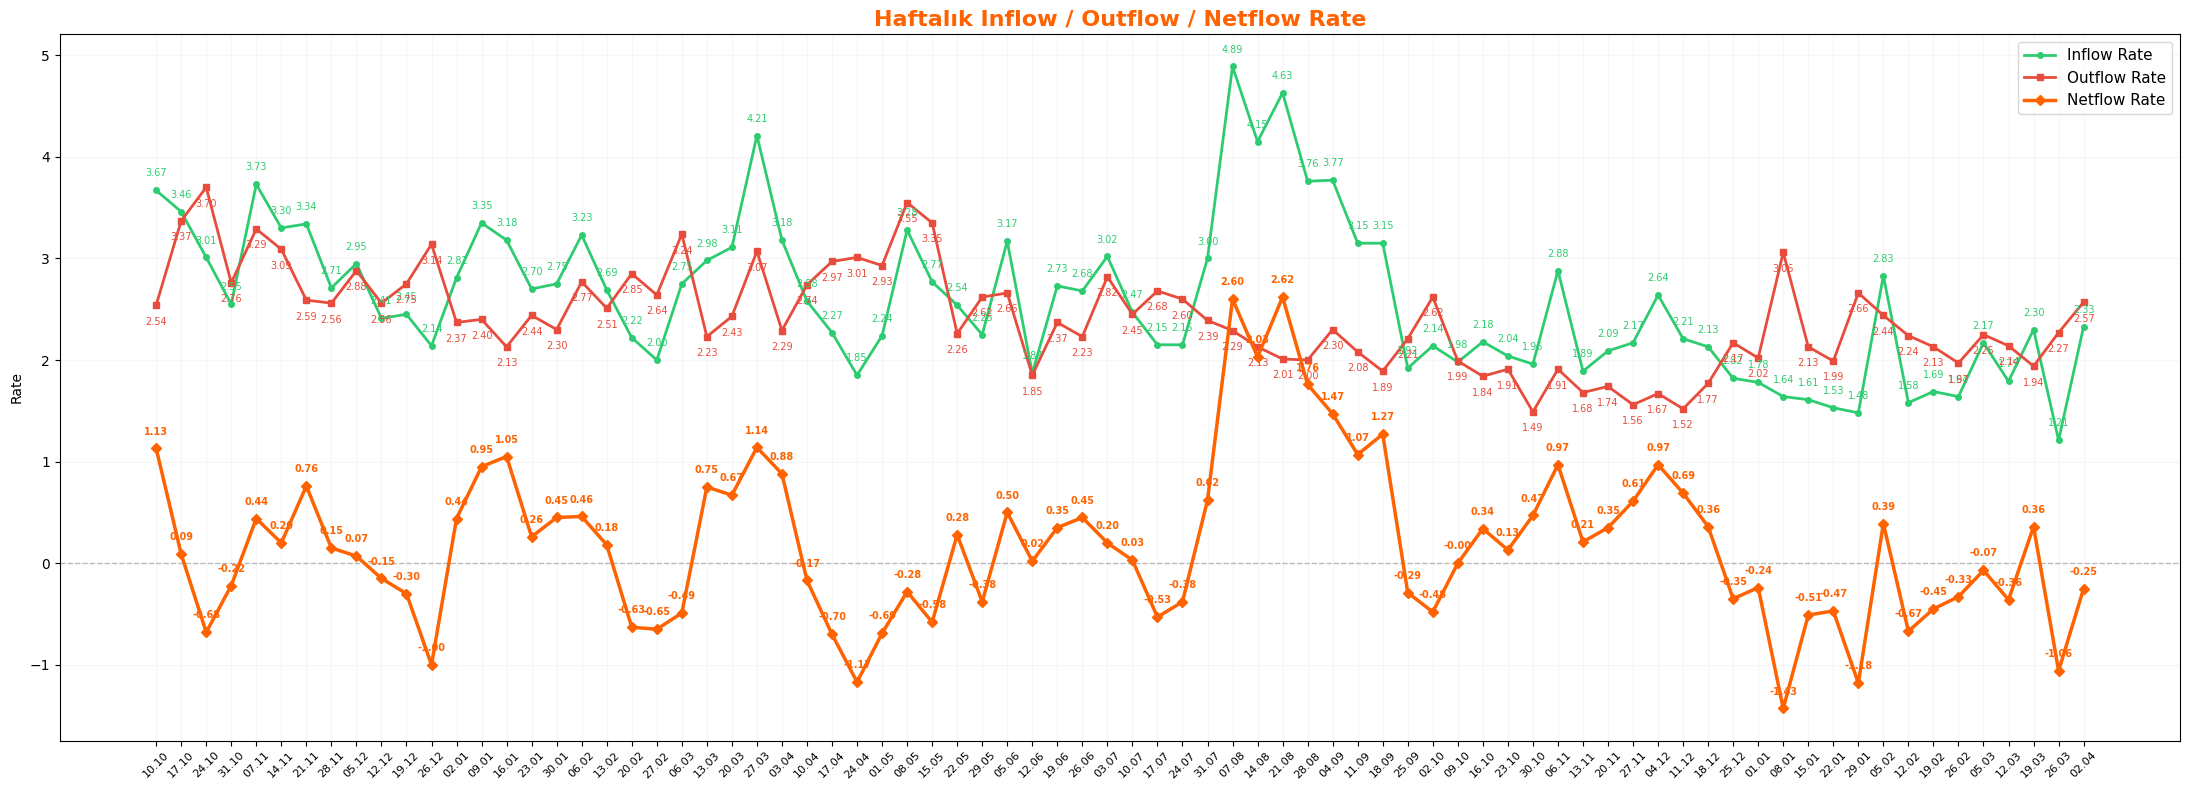

In [3]:
# 1. Veri Kaynaklarını Yükle
df_macro = pd.read_excel('FORA_MODEL_FINAL.xlsx')            # Makro & piyasa verileri
df_internal = pd.read_csv('internal_dataset.csv').round(2)    # Banka iç verileri

# 2. Tarih Standardizasyonu
df_macro['Date'] = pd.to_datetime(df_macro['Max Tarih'], format='mixed', dayfirst=True)
df_internal['Date'] = pd.to_datetime(df_internal['max_tarih'], format='mixed', dayfirst=True)

# 3. Veri Birleştirme
# Makro tarafından tarih ve hedef kolonları düşür (iç veriden gelecek)
cols_to_drop_macro = [c for c in ['Max Tarih', 'Min Tarih', 'netflow_rate', 'total_inflow_rate', 'total_outflow_rate'] if c in df_macro.columns]
df = pd.merge(
    df_macro.drop(columns=cols_to_drop_macro),
    df_internal,
    on='Date',
    how='outer'
).sort_values('Date').reset_index(drop=True)

# Hedef değişkeni standart isme çevir
df = df.rename(columns={'netflow_rate': 'NET'})

# Kolon sıralaması: tarih ve hedef önce
cols_front = ['Date', 'min_tarih', 'max_tarih', 'NET']
other_cols = [c for c in df.columns if c not in cols_front]
df = df[cols_front + other_cols]

# Hedef değişkeni boş olan satırları çıkar (ilk birkaç hafta boşluk olabilir)
df = df.dropna(subset=['NET']).reset_index(drop=True)

# Kaynak Özeti
print(f"Veri Kaynakları Özeti:")
print(f"  Makro Veri    : {len(df_macro)} hafta ({df_macro['Date'].min().strftime('%d.%m.%Y')} → {df_macro['Date'].max().strftime('%d.%m.%Y')})")
print(f"  İç Veri       : {len(df_internal)} hafta ({df_internal['Date'].min().strftime('%d.%m.%Y')} → {df_internal['Date'].max().strftime('%d.%m.%Y')})")
print(f"  Birleşik Matris: {len(df)} hafta (hedef hizalı)")

# 4. İlk ve Son Satırlar
display(df.head(5).style.format({
    'Date': lambda x: x.strftime('%d.%m.%Y'),
    'min_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
    'max_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y')
}))
display(df.tail(5).style.format({
    'Date': lambda x: x.strftime('%d.%m.%Y'),
    'min_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
    'max_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y')
}))

# 5. Birleşik Matris Detayları
def fdate(d): return pd.to_datetime(d).strftime('%d.%m.%Y')
print(f"Birleşik Matris Detayları:")
print(f"  Toplam Satır   : {len(df)}")
print(f"  Toplam Değişken: {len(df.columns)}")
print(f"  Hedef Doluluğu : {df['NET'].notna().sum()} / {len(df)} dolu gözlem")
print(f"  Başlangıç      : {fdate(df['min_tarih'].iloc[0])} – {fdate(df['max_tarih'].iloc[0])}")
print(f"  Bitiş          : {fdate(df['min_tarih'].iloc[-1])} – {fdate(df['max_tarih'].iloc[-1])}")

# 6. Inflow / Outflow / Netflow Tek Grafik
fig, ax = plt.subplots(figsize=(22, 8))

dates = df['Date']

if 'total_inflow_rate' in df.columns:
    ax.plot(dates, df['total_inflow_rate'], color='#2ecc71', linewidth=2, marker='o', markersize=4, label='Inflow Rate')
    for x, y in zip(dates, df['total_inflow_rate']):
        ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0, 10), fontsize=7, color='#2ecc71', ha='center')

if 'total_outflow_rate' in df.columns:
    ax.plot(dates, df['total_outflow_rate'], color='#e74c3c', linewidth=2, marker='s', markersize=4, label='Outflow Rate')
    for x, y in zip(dates, df['total_outflow_rate']):
        ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0, -14), fontsize=7, color='#e74c3c', ha='center')

ax.plot(dates, df['NET'], color='#ff6200', linewidth=2.5, marker='D', markersize=5, label='Netflow Rate', zorder=5)
for x, y in zip(dates, df['NET']):
    ax.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0, 10), fontsize=7, color='#ff6200', ha='center', fontweight='bold')

ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('Haftalık Inflow / Outflow / Netflow Rate', fontsize=16, fontweight='bold', color='#ff6200')
ax.set_ylabel('Rate')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.1)
plt.xticks(dates, [d.strftime('%d.%m') for d in dates], rotation=45, fontsize=8)
fig.tight_layout()
plt.show()
plt.close(fig)

<h2 style="color: rgb(255,98,0)">Outlier Audit</h2>

Netflow Rate bir fark serisi olduğu için (Inflow − Outflow) küçük değişimler bile büyük sıçramalar yaratabilir. 
Aşağıda en uç haftalar tek tek inceleniyor: bu haftalar veri hatası mı, yoksa açıklanabilir iş olayları mı?

Amaç silmek değil, anlamak. Eğer spike'lar kampanya/faiz şoku/çeyrek sonu gibi gerçek olaylara denk geliyorsa modelde kalmalı.

NET Dağılım Özeti:
  Ortalama : 0.1801
  Medyan   : 0.1650
  Std      : 0.7930
  Min      : -1.4300
  Max      : 2.6200
  IQR Band : [-1.8113, 2.0187]
  IQR Dışı : 3 hafta
  Z > 2.0  : 4 hafta

En Yüksek 5 Netflow Haftası:


,Date,min_tarih,max_tarih,NET,z_score,total_inflow_rate,total_outflow_rate,toplam_ntb,opening_account,avg_vadeli_bakiye,Payday,YearEnd,Ramazan,PPK_Haftasi,Market_Anomaly
45,21.08.2025,15.08.2025,21.08.2025,2.620000,3.080000,4.630000,2.010000,868.000000,3267.000000,46020.710000,1,0,0,0,0
43,07.08.2025,01.08.2025,07.08.2025,2.600000,3.050000,4.890000,2.290000,598.000000,2649.000000,36393.740000,1,0,0,0,0
44,14.08.2025,08.08.2025,14.08.2025,2.030000,2.330000,4.150000,2.130000,592.000000,2508.000000,40873.480000,0,0,0,0,0
46,28.08.2025,22.08.2025,28.08.2025,1.760000,1.990000,3.760000,2.000000,787.000000,2981.000000,50749.900000,0,0,0,0,0
47,04.09.2025,29.08.2025,04.09.2025,1.470000,1.630000,3.770000,2.300000,767.000000,2935.000000,54766.830000,1,0,0,0,0



En Düşük 5 Netflow Haftası:


,Date,min_tarih,max_tarih,NET,z_score,total_inflow_rate,total_outflow_rate,toplam_ntb,opening_account,avg_vadeli_bakiye,Payday,YearEnd,Ramazan,PPK_Haftasi,Market_Anomaly
65,08.01.2026,02.01.2026,08.01.2026,-1.430000,2.030000,1.640000,3.060000,376.000000,1571.000000,74191.100000,0,0,0,0,0
68,29.01.2026,23.01.2026,29.01.2026,-1.180000,1.720000,1.480000,2.660000,440.000000,1897.000000,65829.560000,0,0,0,0,0
28,24.04.2025,18.04.2025,24.04.2025,-1.170000,1.700000,1.850000,3.010000,228.000000,1143.000000,36948.780000,0,0,0,0,1
76,26.03.2026,20.03.2026,26.03.2026,-1.060000,1.560000,1.210000,2.270000,239.000000,1332.000000,58047.760000,0,0,0,0,0
11,26.12.2024,20.12.2024,26.12.2024,-1.000000,1.490000,2.140000,3.140000,462.000000,1987.000000,31042.280000,0,1,0,0,0


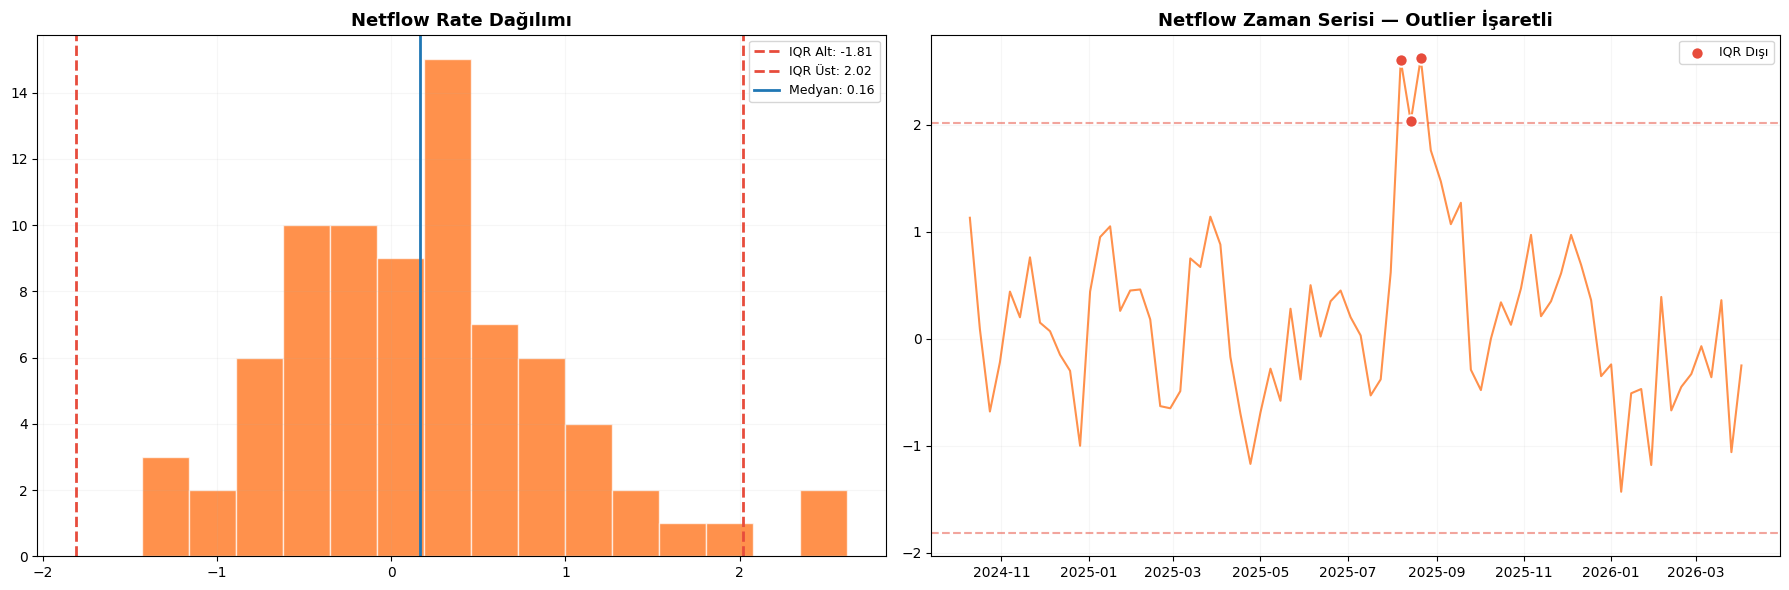

In [4]:
# Outlier Tespiti (IQR ve Z-Score)
Q1, Q3 = df['NET'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
z_scores = np.abs((df['NET'] - df['NET'].mean()) / df['NET'].std())

# Uç haftaları işaretle
df['is_outlier_iqr'] = (df['NET'] < lower) | (df['NET'] > upper)
df['z_score'] = z_scores.round(2)

# Temel istatistikler
print(f"NET Dağılım Özeti:")
print(f"  Ortalama : {df['NET'].mean():.4f}")
print(f"  Medyan   : {df['NET'].median():.4f}")
print(f"  Std      : {df['NET'].std():.4f}")
print(f"  Min      : {df['NET'].min():.4f}")
print(f"  Max      : {df['NET'].max():.4f}")
print(f"  IQR Band : [{lower:.4f}, {upper:.4f}]")
print(f"  IQR Dışı : {df['is_outlier_iqr'].sum()} hafta")
print(f"  Z > 2.0  : {(z_scores > 2).sum()} hafta")
print()

# Uç haftaların detayları
audit_cols = ['Date', 'min_tarih', 'max_tarih', 'NET', 'z_score']
# Varsa inflow/outflow ve iç metrikleri de ekle
for col in ['total_inflow_rate', 'total_outflow_rate', 'toplam_ntb', 'opening_account', 'avg_vadeli_bakiye',
            'Payday', 'YearEnd', 'Ramazan', 'PPK_Haftasi', 'Market_Anomaly']:
    if col in df.columns:
        audit_cols.append(col)

# En yüksek 5 + en düşük 5 hafta
top5 = df.nlargest(5, 'NET')[audit_cols]
bot5 = df.nsmallest(5, 'NET')[audit_cols]

print("En Yüksek 5 Netflow Haftası:")
display(top5.style.format({
    'Date': lambda x: x.strftime('%d.%m.%Y'),
    'min_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
    'max_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y')
}))

print("\nEn Düşük 5 Netflow Haftası:")
display(bot5.style.format({
    'Date': lambda x: x.strftime('%d.%m.%Y'),
    'min_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
    'max_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y')
}))

# Görselleştirme: NET dağılımı + outlier sınırları
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Sol: Histogram + IQR sınırları
axes[0].hist(df['NET'], bins=15, alpha=0.7, color='#ff6200', edgecolor='white')
axes[0].axvline(lower, color='#e74c3c', linestyle='--', linewidth=2, label=f'IQR Alt: {lower:.2f}')
axes[0].axvline(upper, color='#e74c3c', linestyle='--', linewidth=2, label=f'IQR Üst: {upper:.2f}')
axes[0].axvline(df['NET'].median(), color='#1f77b4', linestyle='-', linewidth=2, label=f'Medyan: {df["NET"].median():.2f}')
axes[0].set_title('Netflow Rate Dağılımı', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.1)

# Sağ: Zaman serisi + outlier işaretleme
axes[1].plot(df['Date'], df['NET'], color='#ff6200', linewidth=1.5, alpha=0.7)
outlier_mask = df['is_outlier_iqr']
axes[1].scatter(df.loc[outlier_mask, 'Date'], df.loc[outlier_mask, 'NET'],
                color='#e74c3c', s=80, zorder=5, edgecolors='white', linewidth=1.5, label='IQR Dışı')
axes[1].axhline(upper, color='#e74c3c', linestyle='--', alpha=0.5)
axes[1].axhline(lower, color='#e74c3c', linestyle='--', alpha=0.5)
axes[1].set_title('Netflow Zaman Serisi — Outlier İşaretli', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.1)

fig.tight_layout()
plt.show()
plt.close(fig)

# Temizlik: geçici kolonları kaldır
df = df.drop(columns=['is_outlier_iqr', 'z_score'])

<h2 style="color: rgb(255,98,0)">Türetilmiş Değişkenler (Feature Engineering)</h2>

Bu adımda faiz dönüşümleri ve taktik spread hesaplamaları yapılarak ürünün piyasa benchmark'larına göre 
göreli çekiciliği ölçülür.

In [5]:
# Bileşik / Basit faiz dönüşümleri
df["TLREF_Bilesik"] = ((1 + df["TLREF"] / 100) ** (365/365) - 1) * 100  # TLREF'i bileşik faize çevir
df["TCMB_1M_Basit"] = ((1 + df["TCMB 1M"] / 100) ** (30/365) - 1) / (30/365) * 100
df["TCMB_3M_Basit"] = ((1 + df["TCMB 3M"] / 100) ** (90/365) - 1) / (90/365) * 100

# OSA welcome yıllıklandırılmış faiz (basit → bileşik)
df["osawelcomeannual"] = ((1 + df["osawelcome"] / 100 * 32/365) ** (365/32) - 1) * 100
df["osawelcomewcurrent"] = ((1 + df["osawelcomeannualwcurrent"] / 100) ** (32/365) - 1) * (365/32) * 100

# Spread hesaplamaları: ürün faizinin piyasa benchmark'larına göreli konumu
df["w/TLREF"] = df["osawelcomeannual"] - df["TLREF_Bilesik"]       # Welcome vs TLREF farkı
df["w/1month"] = df["osawelcomeannual"] - df["TCMB 1M"]            # Welcome vs TCMB 1 aylık farkı
df["w/3month"] = df["osawelcomeannual"] - df["TCMB 3M"]            # Welcome vs TCMB 3 aylık farkı

# Piyasa benchmark'ına göre nominal fark
df["osawelcome-benchmark"] = df["osawelcome"] - df["Benchmark"]

# Mevcut müşteri welcome spread'leri (delta bazlı)
df["w/TLREF(deltas)"] = df["osawelcomeannualwcurrent"] - df["TLREF_Bilesik"]
df["w/1month(deltas)"] = df["osawelcomeannualwcurrent"] - df["TCMB 1M"]
df["w/3month(deltas)"] = df["osawelcomeannualwcurrent"] - df["TCMB 3M"]

# TCMB basit faiz vs TLREF spread'leri
df["<1month-TLREF"] = df["TCMB_1M_Basit"] - df["TLREF"]
df["<3month-TLREF"] = df["TCMB_3M_Basit"] - df["TLREF"]

# İlk ve son satırlar
display(df.head(5).style.format({
    'Date': lambda x: x.strftime('%d.%m.%Y'),
    'min_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
    'max_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y')
}))
display(df.tail(5).style.format({
    'Date': lambda x: x.strftime('%d.%m.%Y'),
    'min_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y'),
    'max_tarih': lambda x: pd.to_datetime(x).strftime('%d.%m.%Y')
}))

# Matris Detayları
def fdate(d): return pd.to_datetime(d).strftime('%d.%m.%Y')
print(f"Matris Detayları:")
print(f"  Toplam Satır   : {len(df)}")
print(f"  Toplam Değişken: {len(df.columns)}")
print(f"  Hedef Doluluğu : {df['NET'].notna().sum()} / {len(df)} dolu gözlem")
print(f"  Başlangıç      : {fdate(df['min_tarih'].iloc[0])} – {fdate(df['max_tarih'].iloc[0])}")
print(f"  Bitiş          : {fdate(df['min_tarih'].iloc[-1])} – {fdate(df['max_tarih'].iloc[-1])}")

,Date,min_tarih,max_tarih,NET,TLREF,AOFF,PP Getiri,TCMB 1M,TCMB 3M,Benchmark,BIST100,Spot Kredi,WebTufe,Sepet Kur,Full Workday,Benchmark_All,TCMB_Politika,Altin_USD,VIX,XBANK,EUR_USD,USD_TRY,EUR_TRY,Bakir,Gumus,Brent,DXY,BIST100_yf,Kur_Vol,Gram_Altin_TRY,BIST_Vol,KKO,Tuketici_Guven,Net_Rezerv,Sanayi_Uretim,Ihtiyac_Kredi_Faizi,Fin_Guven,Cekirdek_Enflasyon,Enflasyon_Beklenti_12ay,GSYH_Buyume_Beklenti,Issizlik,GT_Mevduat_Faizi,GT_En_Yuksek,CDS_5Y,WebTufe_TUFE_Aylik,WebTufe_Gida_Endeks,WebTufe_Enerji_Endeks,WebTufe_Ulastirma_Endeks,WebTufe_Hizmet_Endeks,WebTufe_Giyim_Endeks,WebTufe_Endeks,WebTufe_KisiselBakim_Endeks,WebTufe_Aclik_Siniri,BKM_Giyim_TL,BKM_Yemek_TL,BKM_Kozmetik_TL,Payday,Tax_Season,Holiday_Cash,Season,Month,YearEnd,School_Vacation,Quarter_End,Ramazan,Bayram_Haftasi,Asgari_Ucret_Zam,Black_Friday,Turizm_Sezonu,Temetu_Donemi,PPK_Haftasi,Kis_Indirim,Market_Anomaly,Faiz_Anomaly,Market_Stress,TLREF_lag1,TLREF_lag2,TLREF_lag4,TCMB1M_lag1,TLREF_x_KurVol,Faiz_Spread,Reel_Faiz,BIST100_Getiri,Altin_Getiri,Kur_Degisim,Sepet_Kur_Degisim,Reel_Giyim,Lipstick_Ratio,Reel_Yemek,Reel_Kozmetik,Gida_Spread,Enerji_Spread,Hizmet_vs_Gida,Zorunlu_Harcama_Baskisi,Kur_Spike,Altin_Rush,CDS_Spike,Enflasyon_Sok,Likidite_Sikisma,log_BIST100,log_Gram_Altin_TRY,TCMB_1M_lag1,TCMB_1M_lag2,TCMB_1M_lag4,AOFF_lag1,AOFF_lag2,AOFF_lag4,Altin_Getiri_lag1,Altin_Getiri_lag2,Altin_Getiri_lag4,BIST100_Getiri_lag1,BIST100_Getiri_lag2,BIST100_Getiri_lag4,Kur_Degisim_lag1,Kur_Degisim_lag2,Kur_Degisim_lag4,Reel_Faiz_lag1,Reel_Faiz_lag2,Reel_Faiz_lag4,Faiz_Spread_lag1,Faiz_Spread_lag2,Faiz_Spread_lag4,CDS_5Y_lag1,CDS_5Y_lag2,CDS_5Y_lag4,VIX_lag1,VIX_lag2,VIX_lag4,TCMB_Politika_lag1,TCMB_Politika_lag2,TCMB_Politika_lag4,Enflasyon_Beklenti_12ay_lag1,Enflasyon_Beklenti_12ay_lag2,Enflasyon_Beklenti_12ay_lag4,GSYH_Buyume_Beklenti_lag1,GSYH_Buyume_Beklenti_lag2,GSYH_Buyume_Beklenti_lag4,TLREF_roll4_mean,TLREF_roll4_std,BIST100_Getiri_roll4_mean,BIST100_Getiri_roll4_std,Altin_Getiri_roll4_mean,Altin_Getiri_roll4_std,Kur_Vol_roll4_mean,Kur_Vol_roll4_std,Kur_Degisim_roll4_mean,Kur_Degisim_roll4_std,CDS_5Y_roll4_mean,CDS_5Y_roll4_std,TLREF_delta1,TCMB_1M_delta1,WebTufe_delta1,CDS_5Y_delta1,TCMB_Politika_delta1,osabook_basit,osabook,toplam_cof_basit,avg_vadeli_bakiye,avg_vadesiz_bakiye,avg_vadeli_tl,avg_th_total,avg_vdeli_spread,avg_vdesiz_dahil_spread,osawelcome,osawelcomeannual,osawelcomeannualwcurrent,osaftp,maliyet_hosgeldin_orani,toplam_ntb,toplam_existing,opening_account,is_gunu_sayisi,total_inflow_rate,total_outflow_rate,TLREF_Bilesik,TCMB_1M_Basit,TCMB_3M_Basit,osawelcomewcurrent,w/TLREF,w/1month,w/3month,osawelcome-benchmark,w/TLREF(deltas),w/1month(deltas),w/3month(deltas),<1month-TLREF,<3month-TLREF
0,10.10.2024,04.10.2024,10.10.2024,1.130000,49.859620,50.000000,0.007986,54.800000,59.760000,nan,9207.490000,60.730000,3.287900,35.749250,1,nan,45.000000,2626.440000,21.012000,13032.340000,1.098100,34.243700,37.594500,4.438700,31.131600,78.428000,102.706000,9056.391800,0.000732,2891.600000,0.020082,74.900000,80.550000,3361177350,104.080000,71.090000,167.600000,1.387900,27.440000,3.120000,8.800000,76,77,259.760000,3.287900,87.172800,78.461800,87.123900,83.548000,88.039800,85.776500,84.323200,20590.700000,97406.110000,89826.080000,51756.890000,0,0,0,4,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0.356400,49.621640,48.657440,nan,54.840000,0.036500,4.940400,nan,-6.835400,-0.745200,0.159700,-0.374100,1316.704700,0.531400,1105.741500,748.419300,1.016278,0.914724,0.958418,0.965501,0,0,0,0,0,9.127881,7.969911,54.840000,54.740000,nan,50.000000,50.000000,nan,0.417100,2.962700,nan,0.876200,2.160900,nan,0.226900,0.299600,nan,nan,nan,nan,5.218400,6.082600,nan,259.760000,259.760000,259.760000,18.468000,15.642000,nan,45.000000,45.000000,45.000000,27.468600,27.490000,nan,3.160000,3.190000,nan,48.974600,0.962300,-1.266100,4.865700,0.878200,1.896500,0.001200,0.000300,0.228700,0.070000,259.535000,0.318200,0.238000,-0.040000,0.000000,-0.450000,0.000000,48.220000,61.910000,43.870000,30548.200000,3028.430000

,Date,min_tarih,max_tarih,NET,TLREF,AOFF,PP Getiri,TCMB 1M,TCMB 3M,Benchmark,BIST100,Spot Kredi,WebTufe,Sepet Kur,Full Workday,Benchmark_All,TCMB_Politika,Altin_USD,VIX,XBANK,EUR_USD,USD_TRY,EUR_TRY,Bakir,Gumus,Brent,DXY,BIST100_yf,Kur_Vol,Gram_Altin_TRY,BIST_Vol,KKO,Tuketici_Guven,Net_Rezerv,Sanayi_Uretim,Ihtiyac_Kredi_Faizi,Fin_Guven,Cekirdek_Enflasyon,Enflasyon_Beklenti_12ay,GSYH_Buyume_Beklenti,Issizlik,GT_Mevduat_Faizi,GT_En_Yuksek,CDS_5Y,WebTufe_TUFE_Aylik,WebTufe_Gida_Endeks,WebTufe_Enerji_Endeks,WebTufe_Ulastirma_Endeks,WebTufe_Hizmet_Endeks,WebTufe_Giyim_Endeks,WebTufe_Endeks,WebTufe_KisiselBakim_Endeks,WebTufe_Aclik_Siniri,BKM_Giyim_TL,BKM_Yemek_TL,BKM_Kozmetik_TL,Payday,Tax_Season,Holiday_Cash,Season,Month,YearEnd,School_Vacation,Quarter_End,Ramazan,Bayram_Haftasi,Asgari_Ucret_Zam,Black_Friday,Turizm_Sezonu,Temetu_Donemi,PPK_Haftasi,Kis_Indirim,Market_Anomaly,Faiz_Anomaly,Market_Stress,TLREF_lag1,TLREF_lag2,TLREF_lag4,TCMB1M_lag1,TLREF_x_KurVol,Faiz_Spread,Reel_Faiz,BIST100_Getiri,Altin_Getiri,Kur_Degisim,Sepet_Kur_Degisim,Reel_Giyim,Lipstick_Ratio,Reel_Yemek,Reel_Kozmetik,Gida_Spread,Enerji_Spread,Hizmet_vs_Gida,Zorunlu_Harcama_Baskisi,Kur_Spike,Altin_Rush,CDS_Spike,Enflasyon_Sok,Likidite_Sikisma,log_BIST100,log_Gram_Altin_TRY,TCMB_1M_lag1,TCMB_1M_lag2,TCMB_1M_lag4,AOFF_lag1,AOFF_lag2,AOFF_lag4,Altin_Getiri_lag1,Altin_Getiri_lag2,Altin_Getiri_lag4,BIST100_Getiri_lag1,BIST100_Getiri_lag2,BIST100_Getiri_lag4,Kur_Degisim_lag1,Kur_Degisim_lag2,Kur_Degisim_lag4,Reel_Faiz_lag1,Reel_Faiz_lag2,Reel_Faiz_lag4,Faiz_Spread_lag1,Faiz_Spread_lag2,Faiz_Spread_lag4,CDS_5Y_lag1,CDS_5Y_lag2,CDS_5Y_lag4,VIX_lag1,VIX_lag2,VIX_lag4,TCMB_Politika_lag1,TCMB_Politika_lag2,TCMB_Politika_lag4,Enflasyon_Beklenti_12ay_lag1,Enflasyon_Beklenti_12ay_lag2,Enflasyon_Beklenti_12ay_lag4,GSYH_Buyume_Beklenti_lag1,GSYH_Buyume_Beklenti_lag2,GSYH_Buyume_Beklenti_lag4,TLREF_roll4_mean,TLREF_roll4_std,BIST100_Getiri_roll4_mean,BIST100_Getiri_roll4_std,Altin_Getiri_roll4_mean,Altin_Getiri_roll4_std,Kur_Vol_roll4_mean,Kur_Vol_roll4_std,Kur_Degisim_roll4_mean,Kur_Degisim_roll4_std,CDS_5Y_roll4_mean,CDS_5Y_roll4_std,TLREF_delta1,TCMB_1M_delta1,WebTufe_delta1,CDS_5Y_delta1,TCMB_Politika_delta1,osabook_basit,osabook,toplam_cof_basit,avg_vadeli_bakiye,avg_vadesiz_bakiye,avg_vadeli_tl,avg_th_total,avg_vdeli_spread,avg_vdesiz_dahil_spread,osawelcome,osawelcomeannual,osawelcomeannualwcurrent,osaftp,maliyet_hosgeldin_orani,toplam_ntb,toplam_existing,opening_account,is_gunu_sayisi,total_inflow_rate,total_outflow_rate,TLREF_Bilesik,TCMB_1M_Basit,TCMB_3M_Basit,osawelcomewcurrent,w/TLREF,w/1month,w/3month,osawelcome-benchmark,w/TLREF(deltas),w/1month(deltas),w/3month(deltas),<1month-TLREF,<3month-TLREF
73,05.03.2026,27.02.2026,05.03.2026,-0.070000,39.325040,37.000000,0.005560,42.970000,44.380000,42.147778,13903.750000,49.000000,2.479500,47.447450,1,nan,20.000000,5163.560000,21.954000,18457.519500,1.170200,43.951400,51.442000,5.856100,85.641800,79.686000,98.626000,13203.940200,0.000946,7296.460000,0.014366,73.357100,85.225700,4523866755,107.960000,56.790000,163.928600,1.188500,22.150000,3.857100,9.000000,34,41,238.570000,2.479500,127.787900,125.508900,118.911000,119.686500,105.342500,121.254000,121.372500,32534.250000,118699.400000,125211.190000,90274.240000,1,0,0,2,3,0,0,0,1,0,0,0,0,0,1,0,0,0,0.164700,36.825120,36.712340,36.908400,43.290000,0.037200,3.645000,0.797600,-1.482300,0.306800,0.248200,-0.648700,1126.795000,0.760500,1046.159700,743.778400,1.053886,1.035091,0.936603,1.044488,0,0,0,0,1,9.539986,8.895282,43.290000,43.430000,43.460000,37.000000,37.000000,37.000000,4.150000,-0.320700,-6.521300,1.118200,1.877100,5.044900,0.262100,0.327900,0.227000,-0.119300,-0.128700,-0.112400,6.464900,6.717700,6.551600,224.310000,217.080000,217.580000,19.242000,20.185000,18.438000,20.000000,20.000000,20.000000,22.100000,22.100000,22.128600,3.900000,3.900000,3.894300,37.436700,1.260900,0.800400,1.555600,2.113200,2.462400,0.001300,0.000500,0.267400,0.042300,223.645000,10.766400,2.499

Matris Detayları:
  Toplam Satır   : 78
  Toplam Değişken: 187
  Hedef Doluluğu : 78 / 78 dolu gözlem
  Başlangıç      : 04.10.2024 – 10.10.2024
  Bitiş          : 27.03.2026 – 02.04.2026


<h2 style="color: rgb(255,98,0)">Eksik Veri Yönetimi (NaN)</h2>

Zaman serisi yapısına uygun şekilde eksik değerler ileri/geri doldurma (forward/backward fill) ile tamamlanır. 
Modelin her hafta tutarlı bir feature seti görmesi sağlanır.

In [6]:
# Önce aylık/çeyreklik makro göstergeleri doldur (Reel_Faiz hesabından ÖNCE yapılmalı)
macro_ffill = [
    'KKO', 'Tuketici_Guven', 'Net_Rezerv', 'Sanayi_Uretim',
    'Ihtiyac_Kredi_Faizi', 'Fin_Guven', 'Cekirdek_Enflasyon',
    'Enflasyon_Beklenti_12ay', 'GSYH_Buyume_Beklenti', 'Issizlik',
    'BIST_Vol', 'WebTufe_TUFE_Aylik',
    'WebTufe_Gida_Endeks', 'WebTufe_Enerji_Endeks',
    'WebTufe_Ulastirma_Endeks', 'WebTufe_Hizmet_Endeks',
    'WebTufe_Giyim_Endeks', 'WebTufe_Endeks',
    'WebTufe_KisiselBakim_Endeks', 'WebTufe_Aclik_Siniri',
    'BKM_Giyim_TL', 'BKM_Yemek_TL', 'BKM_Kozmetik_TL',
    'WebTufe'
]
macro_ffill = [c for c in macro_ffill if c in df.columns]
df[macro_ffill] = df[macro_ffill].ffill()

# Reel Faiz: TLREF yıllık, WebTüfe aylık → yıllığa çevirip fark al (ffill sonrası)
df['Reel_Faiz'] = (df['TLREF'] - df['WebTufe'] * 12).round(4)
for lag in [1, 2, 4]:
    df[f'Reel_Faiz_lag{lag}'] = df['Reel_Faiz'].shift(lag)  # Her durumda yeniden hesapla

# Benchmark: boş haftaları TLREF + sabit medyan spread ile doldur
mask = df['Benchmark'].notna()
spread = (df.loc[mask, 'Benchmark'] - df.loc[mask, 'TLREF']).median()
df['Benchmark'] = df['Benchmark'].fillna(df['TLREF'] + spread)
df['osawelcome-benchmark'] = df['osawelcome'] - df['Benchmark']

# Benchmark_All tamamen boşsa düşür
if 'Benchmark_All' in df.columns and df['Benchmark_All'].isna().mean() > 0.5:
    df = df.drop(columns=['Benchmark_All'])

# Kur_Vol tek NaN satırını interpolasyon ile doldur
if 'Kur_Vol' in df.columns:
    df['Kur_Vol'] = df['Kur_Vol'].interpolate()
if 'TLREF_x_KurVol' in df.columns and 'Kur_Vol' in df.columns:
    df['TLREF_x_KurVol'] = df['TLREF'] * df['Kur_Vol']

# Isınma satırları: lag4 kolonları yüzünden sadece ilk 4 satır NaN olur
df = df.iloc[4:].reset_index(drop=True)

# Kalan NaN'ları ffill + bfill ile temizle (çok az kalmışsa)
remaining_nan = df.isna().sum().sum()
if remaining_nan > 0:
    df = df.ffill().bfill()

# Eksik Veri Yönetimi Özeti
def fdate(d): return pd.to_datetime(d).strftime('%d.%m.%Y')
nan_count = df.isna().sum().sum()
print(f"Eksik Veri Yönetimi Özeti:")
print(f"  Benchmark Spread : {spread:.4f}")
print(f"  Toplam Satır     : {len(df)}")
print(f"  Toplam Değişken  : {len(df.columns)}")
print(f"  Kalan NaN        : {nan_count}")
print(f"  Başlangıç        : {fdate(df['min_tarih'].iloc[0])} – {fdate(df['max_tarih'].iloc[0])}")
print(f"  Bitiş            : {fdate(df['min_tarih'].iloc[-1])} – {fdate(df['max_tarih'].iloc[-1])}")

# Haftalık Süreklilik Kontrolü
diff_series = df['Date'].diff().dt.days
diffs = diff_series.dropna()
gaps = df[diff_series > 8]

if len(gaps) == 0:
    print(f"  Süreklilik       : ✓ Boşluk yok — her hafta mevcut (tüm farklar {int(diffs.min())} gün)")
else:
    print(f"{len(gaps)} haftalık boşluk tespit edildi:")
    for idx in gaps.index:
        prev = df.loc[idx-1, 'Date'].strftime('%d.%m.%Y')
        curr = df.loc[idx, 'Date'].strftime('%d.%m.%Y')
        print(f"    {prev} → {curr} ({int(diff_series.loc[idx])} gün)")

print("\nManuel Kontrol İçin Tarih Aralıkları:")
check_df = pd.DataFrame({
    'Önceki Tarih': df['Date'].shift(1).dt.strftime('%d.%m.%Y'),
    'Mevcut Tarih': df['Date'].dt.strftime('%d.%m.%Y'),
    'Gün Farkı': diff_series
})
display(check_df.dropna().style.format({'Gün Farkı': '{:.0f}'}))

Eksik Veri Yönetimi Özeti:
  Benchmark Spread : 3.7373
  Toplam Satır     : 74
  Toplam Değişken  : 186
  Kalan NaN        : 0
  Başlangıç        : 01.11.2024 – 07.11.2024
  Bitiş            : 27.03.2026 – 02.04.2026
  Süreklilik       : ✓ Boşluk yok — her hafta mevcut (tüm farklar 7 gün)

Manuel Kontrol İçin Tarih Aralıkları:


,Önceki Tarih,Mevcut Tarih,Gün Farkı
1,07.11.2024,14.11.2024,7
2,14.11.2024,21.11.2024,7
3,21.11.2024,28.11.2024,7
4,28.11.2024,05.12.2024,7
5,05.12.2024,12.12.2024,7
6,12.12.2024,19.12.2024,7
7,19.12.2024,26.12.2024,7
8,26.12.2024,02.01.2025,7
9,02.01.2025,09.01.2025,7
10,09.01.2025,16.01.2025,7


<h2 style="color: rgb(255,98,0)">Etkileşim Değişkenleri (İç × Dış Çaprazlama)</h2>

Banka iç metrikleri ile makroekonomik göstergelerin çapraz çarpımından türetilen etkileşim değişkenleri. 
Tek başına zayıf olan sinyallerin birleşiminden daha güçlü tahmin gücü elde edilmesi hedeflenir.

In [7]:
# Rekabetçi Faiz × Hacim
df['competitive_x_ntb'] = df['osawelcome-benchmark'] * df['toplam_ntb']           # Benchmark farkı × yeni müşteri
df['competitive_x_opening'] = df['osawelcome-benchmark'] * df['opening_account']   # Benchmark farkı × hesap açılış

# Maliyet Spread'i × Piyasa Stresi
df['vdeli_spread_x_vix'] = df['avg_vdeli_spread'] * df['VIX']             # Vadeli spread × küresel korku
df['vdesiz_spread_x_cds'] = df['avg_vdesiz_dahil_spread'] * df['CDS_5Y']  # Vadesiz dahil spread × ülke riski

# Bakiye İvmesi × Faiz Ortamı
df['vadeli_x_reel_faiz'] = df['avg_vadeli_bakiye'] * df['Reel_Faiz']      # Vadeli bakiye × reel faiz

# Müşteri Davranış Oranları
df['ntb_ratio'] = df['toplam_ntb'] / df['opening_account'].replace(0, np.nan)  # Yeni müşteri / hesap açılış oranı
df['ntb_ratio'] = df['ntb_ratio'].fillna(0)
df['maliyet_x_welcome'] = df['maliyet_hosgeldin_orani'] * df['osawelcome']     # Maliyet oranı × welcome faizi

# Çapraz Alan Oranları
df['welcome_tlref_ratio'] = df['osawelcome'] / df['TLREF_Bilesik'].replace(0, np.nan)  # Welcome / TLREF oranı
df['welcome_tlref_ratio'] = df['welcome_tlref_ratio'].fillna(0)

# Alternatif Yatırım Rekabeti
df['welcome_vs_gold'] = df['osawelcomeannual'] - df['Altin_Getiri'] * 52    # Welcome vs altın yıllık getiri
df['welcome_vs_bist'] = df['osawelcomeannual'] - df['BIST100_Getiri'] * 52  # Welcome vs BIST100 yıllık getiri

# Mevduat Yapısal Karışımı
df['vadesiz_vadeli_ratio'] = df['avg_vadesiz_bakiye'] / df['avg_vadeli_bakiye'].replace(0, np.nan)  # Vadesiz / vadeli oranı
df['vadesiz_vadeli_ratio'] = df['vadesiz_vadeli_ratio'].fillna(0)
df['vadeli_concentration'] = df['avg_vadeli_bakiye'] / df['avg_th_total'].replace(0, np.nan)        # Vadeli yoğunlaşma
df['vadeli_concentration'] = df['vadeli_concentration'].fillna(0)

# FTP Kârlılık vs Piyasa
df['ftp_vs_tlref'] = df['osaftp'] - df['TLREF']                            # FTP − TLREF farkı

# Kur Stresi × Bakiye
df['kur_x_vadeli'] = df['Kur_Degisim'] * df['avg_vadeli_bakiye']           # Kur değişimi × vadeli bakiye

# Günlük Operasyonel Verimlilik
df['daily_acquisition'] = (df['toplam_ntb'] + df['toplam_existing']) / df['is_gunu_sayisi']  # Günlük müşteri kazanımı

# Ayrıntılı Bileşen Akış Sinyalleri (Inflow ve Outflow Momentum Sinyalleri)
df['inflow_current_week'] = df['total_inflow_rate'].round(2)
df['inflow_lag1'] = df['inflow_current_week'].shift(1).fillna(0).round(2)
df['inflow_lag2'] = df['inflow_current_week'].shift(2).fillna(0).round(2)
df['inflow_roll3'] = df['inflow_current_week'].rolling(3).mean().fillna(0).round(2)

df['outflow_current_week'] = df['total_outflow_rate'].round(2)
df['outflow_lag1'] = df['outflow_current_week'].shift(1).fillna(0).round(2)
df['outflow_lag2'] = df['outflow_current_week'].shift(2).fillna(0).round(2)
df['outflow_roll3'] = df['outflow_current_week'].rolling(3).mean().fillna(0).round(2)

# İç İvme (Haftalık Değişim)
df['welcome_delta'] = df['osawelcome'].diff().fillna(0)                    # Welcome faiz haftalık değişim
df['vadeli_bakiye_delta'] = df['avg_vadeli_bakiye'].pct_change().fillna(0) # Vadeli bakiye yüzdesel değişim
df['ntb_delta'] = df['toplam_ntb'].diff().fillna(0)                        # NTB haftalık fark

# Fiyatlama Agresifliği: Welcome vs Book farkı
df['welcome_book_gap'] = df['osawelcome'] - df['osabook_basit']            # Welcome − Book basit faiz

# Takvim × Rekabetçi Konum
df['competitive_x_payday'] = df['osawelcome-benchmark'] * df['Payday']     # Benchmark farkı × maaş haftası

# Piyasa Stres Bileşik Skoru
df['stress_composite'] = df['Market_Stress'] * df['VIX'] * df['CDS_5Y']   # Stres × VIX × CDS

# Maliyet Ağırlıklı Bakiye
df['cost_weighted_balance'] = df['avg_vadeli_bakiye'] * df['toplam_cof_basit']  # Bakiye × COF

# İleri Düzey İç x Dış Çaprazlamalar (Internal x External)
# 1. Makro Stres ve Likidite Makasları
df['kur_vol_x_vadesiz'] = df['Kur_Vol'] * df['avg_vadesiz_bakiye']                 # Kur oynaklığında vadesizdeki paranın dövize kaçma riski
df['welcome_vs_bist_vol'] = df['osawelcome'] * df['BIST_Vol']                      # Borsa oynaklığı yüksekken garantili mevduat faizinin cazibesi
df['kredi_mevduat_makasi'] = df['Ihtiyac_Kredi_Faizi'] - df['osawelcomeannual']    # İhtiyaç kredisi ile mevduat faizi makası (piyasa likidite darlığı göstergesi)

# 2. Davranışsal Makro Çaprazlamalar
df['welcome_delta_x_guven'] = df['welcome_delta'] * df['Tuketici_Guven']           # Faiz artışına tepkinin, makro tüketici güveni ile çarpımı
df['bakiye_x_enflasyon_bekl'] = df['avg_th_total'] * df['Enflasyon_Beklenti_12ay'] # Bakiyenin enflasyon beklentisine karşı erime/korunma motivasyonu

# 3. Takvim × Müşteri Edinimi / Agresiflik
df['ntb_x_yearend'] = df['toplam_ntb'] * df['YearEnd']                             # Yıl sonu bilanço yarışında gelen müşteri yoğunluğu
df['ntb_x_payday'] = df['toplam_ntb'] * df['Payday']                               # Maaş haftası kaynaklı yeni müşteri girişi
df['ppk_x_welcome_delta'] = df['PPK_Haftasi'] * df['welcome_delta']                # MB Faiz Kararı (PPK) haftasında bankanın kendi faiz aksiyonunun şiddeti

# 4. Makro Bağlam Çaprazlamaları (External x External)
df['kur_enflasyon_sarmali'] = df['Kur_Degisim'] * df['Enflasyon_Beklenti_12ay']    # Kur kaybı ile enflasyon beklentisinin yarattığı çifte TL'den kaçış motivasyonu
df['reel_faiz_x_guven'] = df['Reel_Faiz'] * df['Tuketici_Guven']                   # Reel faizin (pozitif/negatif), tüketici güveni ile yarattığı genel tasarruf iştahı

# 5. Bileşik Takvimsel Basınç (Calendar Compounding)
df['calendar_pressure_score'] = df['Payday'] + df['YearEnd'] + df['Ramazan'] + df['PPK_Haftasi']  # Aynı haftaya denk gelen olayların yoğunluk skoru (Örn: Maaş + PPK)
df['is_event_week'] = (df['calendar_pressure_score'] > 0).astype(int)              # O hafta herhangi bir takvimsel veya regülatif etkinlik var mı? (Binary)

# 6. Etkinlik Haftasında (Event) Müşteri/Faiz İvmesi
df['event_week_x_ntb'] = df['is_event_week'] * df['toplam_ntb']                    # Etkinlik olan haftalarda gelen müşteri hacminin özel ağırlığı
df['event_week_x_welcome'] = df['is_event_week'] * df['welcome_delta']             # Etkinlik haftalarında (PPK/Yıl sonu vb.) faiz değişiminin hızı

# 7. Tüketici Davranışı ve Harcama/Tasarruf İştahı (Macro x Micro)
df['payday_x_reel_faiz'] = df['Payday'] * df['Reel_Faiz']                          # Maaş yattığında reel faiz pozitifse para hesapta kalır, negatifse hızla harcanır (Kritik netflow sinyali)
df['vadesiz_x_enflasyon'] = df['avg_vadesiz_bakiye'] * df['Enflasyon_Beklenti_12ay'] # Vadesizde vadesiz (sıfır faiz) bekleyen paranın enflasyonist ortamda hesabı terk etme motivasyonu
df['sefalet_endeksi_proxy'] = df['Issizlik'] + df['Enflasyon_Beklenti_12ay']       # Makroekonomik zorluk endeksi (Halkın genel tasarruf edebilme kapasitesindeki düşüş/artış)

# 8. Birleşik Alternatif Piyasa Fırsat Maliyeti (Sistemden Çıkış Baskısı)
df['alt_piyasa_baskisi'] = (df['Altin_Getiri'] * 52 + df['BIST100_Getiri'] * 52) - df['osawelcomeannual']  # Mevduata kıyasla borsa ve altının toplam cazibesi (Sistem dışına kaçış)

# 9. Kredi Daralması ve Mevduat Yığılması
df['kredi_faiz_x_ntb'] = df['Ihtiyac_Kredi_Faizi'] * df['toplam_ntb']              # Kredilerin aşırı pahalı olduğu (tüketimin durduğu) dönemde mevduata yönelen yeni müşteri iştahı

# 10. Tüketim Çılgınlığı ve Kredi Kartı Ödeme Baskısı (Outflow Pressure)
if all(c in df.columns for c in ['BKM_Giyim_TL', 'BKM_Yemek_TL', 'BKM_Kozmetik_TL']):
    df['bkm_toplam_harcama'] = df['BKM_Giyim_TL'] + df['BKM_Yemek_TL'] + df['BKM_Kozmetik_TL']
    df['harcama_tehdidi_vadesiz'] = df['bkm_toplam_harcama'] / df['avg_vadesiz_bakiye'].replace(0, np.nan)  # Vadesizde bekleyen paranın ne kadarının kart ödemesine / tüketime gideceğinin riski (Kesin Outflow tehlikesi)

# 11. Reel Sektör İşlem Hacmi (Ticari Döngü)
df['kko_x_sanayi'] = df['KKO'] * df['Sanayi_Uretim']                               # Fabrikalar çalışıyorsa maaş / tedarik ödeme devir hızı (Velocity of Money) artar, vadesiz sirkülasyonu hızlanır

# 12. Sistemik Likidite Stresi ve Makro Güvenlik
df['aoff_tlref_makasi'] = df['AOFF'] - df['TLREF']                                 # Merkez Bankası fonlaması ile piyasa faizi arasındaki makas (Bankacılık sistemindeki nakit/likidite krizinin öncü göstergesi)
df['kur_rezerv_kalkani'] = df['Net_Rezerv'] / df['Kur_Vol'].replace(0, np.nan)     # TCMB Rezervlerinin kur atağını karşılama gücü (Bu düşükse DTH'a yani dolara hücum meyli artar)

# 13. Zorunlu Harcama (Tasarruf Yok Edici) Etkisi
df['gida_enflasyon_baskisi'] = df['WebTufe_Gida_Endeks'] * df['Enflasyon_Beklenti_12ay']  # Gıda/Temel ihtiyaç enflasyonu yüksekse, orta sınıfın kenara para koyma (inflow) kapasitesi sıfırlanır

# 14. Hedefe Yönelik Özel Makro Sinyaller (Composite Metrics)
# Döviz Sepeti Etkisi (0.5 USD + 0.5 EUR)
if 'USD_TRY' in df.columns and 'EUR_TRY' in df.columns:
    df['sepet_kur_05_05'] = (df['USD_TRY'] * 0.5) + (df['EUR_TRY'] * 0.5)
    df['sepet_kur_degisim'] = df['sepet_kur_05_05'].pct_change().fillna(0)
    df['sepet_kur_x_vadesiz'] = df['sepet_kur_degisim'] * df['avg_vadesiz_bakiye']       # Döviz sepeti arttıkça vadesizde kalan paranın DTH'a geçiş (outflow) stresi

# CDS + Kur Volatilitesi + Tüketici Güveni (Kombinasyon)
df['makro_panik_endeksi'] = (df['CDS_5Y'] * df['Kur_Vol']) / df['Tuketici_Guven'].replace(0, np.nan)  

# KKO ve Fiyat Artış Baskısı (Arz Şoku Enflasyonu)
df['kko_arz_soku_baskisi'] = df['Enflasyon_Beklenti_12ay'] / df['KKO'].replace(0, np.nan)             

# Tahvil ile Büyüme Beklentisi Makası 
# (Tahvil faizleri olarak 'Benchmark' kullanıldı)
df['buyume_vs_tahvil'] = df['GSYH_Buyume_Beklenti'] - df['Benchmark']                    # Büyüme ivmesi ile piyasanın tahvil faizi (veya kredi maliyeti) arasındaki çekişme

# Altın / MTM Güvenli Liman Çekiciliği
df['mtm_guvenli_liman_kaos'] = df['BIST_Vol'] * df['Altin_Getiri'].abs()                 # Borsa çok hareketliyken (MTM/Piyasa kaosu) altının hareketlenmesinin birleşimi

# 15. Dinamik İş Sinyalleri (İvme, Kalite ve Gecikmeli Etkiler)
# Göreli Fiyatlama İvmesi (Piyasaya Karşı Pozisyon Alma Tespiti)
df['tcmb_1m_delta'] = df['TCMB 1M'].diff().fillna(0)
df['relative_pricing_momentum'] = df['welcome_delta'] - df['tcmb_1m_delta']       # Biz faizi artırdık ama piyasa (TCMB) daha mı çok artırdı? Gerçek rekabet agresifliği budur.

# Edinilen Müşterinin (NTB) Bakiye Kalitesi ve İç Geçiş (Cannibalization)
df['vadesiz_bakiye_delta'] = df['avg_vadesiz_bakiye'].pct_change().fillna(0)
df['ic_gecis_hareketi'] = df['vadeli_bakiye_delta'] - df['vadesiz_bakiye_delta']  # Pozitifse müşteri vadesizini bozup vadeliye geçiyor (Bizde kalıyor), Negatifse vadesiz boşalıyor (Harcanıyor).
df['welcome_ntb_verimi'] = df['toplam_ntb'] / df['osawelcome'].replace(0, np.nan) # Verilen her 1 puanlık faizin kaç müşteri getirdiği (Fiyatlama Verimliliği / ROI).

# Etkinlik Sonrası Çıkış Riski (Hangover / Post-Event Outflow)
df['post_yearend_hangover'] = df['YearEnd'].shift(1).fillna(0)                    # Yıl sonu / çeyrek sonu hedefleri için giren geçici "şişkin" paranın ertesi hafta çıkış riski.
df['post_payday_hangover'] = df['Payday'].shift(1).fillna(0)                      # Maaş haftası bittikten sonra başlayan standart faturaya/tüketime bağlı gecikmeli outflow sarkması.

# Anlık Kredi Şoku (Credit Shock Outflow)
df['kredi_faiz_soku'] = df['Ihtiyac_Kredi_Faizi'].diff().fillna(0)                # Kredi faizleri aynı hafta aniden fırladığında, tüketicinin kredi çekmek yerine kendi vadelisini bozarak harcama yapma zorunluluğu!

# 16. Bilanço Derinliği, Sıcak Para ve Kar Topu İvmesi (İleri Düzey Endikatörler)
# Ticket Size (Birim Müşteri Kalitesi)
df['ticket_size_bakiye'] = df['avg_vadeli_bakiye'] / df['opening_account'].replace(0, np.nan) 

# Carry Trade / Sıcak Para Cazibesi (Kur Korumalı / Arbitraj)
df['carry_trade_cazibesi'] = df['TLREF_Bilesik'] - (df['Kur_Degisim'] * 52)                   

# Marj Sıkışması ve Operasyonel Frene Basma (Margin Squeeze)
df['ftp_delta'] = df['osaftp'].diff().fillna(0)
df['margin_squeeze'] = df['ftp_delta'] - df['welcome_delta']                                  

# Otoregresif Sinyaller (Netflow momentum)
df['NET_lag1'] = df['NET'].shift(1).fillna(0)                              # Bir önceki hafta netflow
df['NET_lag2'] = df['NET'].shift(2).fillna(0)                              # İki önceki hafta netflow
df['NET_roll3'] = df['NET'].rolling(3).mean().fillna(0).round(2)                    # Son 3 haftanın ortalaması (current + lag1 + lag2)

# Netflow İkinci Türevi (Mevduatın Momentum/MACD Sinyali)
df['netflow_hiz_ivmesi'] = df['NET_lag1'] - df['NET_lag2']                                    

# Hedef Değişken: Bir Sonraki Hafta Tahmini (Veri Sızıntısı Önleme)
# NET kolonunu 1 satır yukarı kaydır → model "bu hafta" verisinden "gelecek hafta" tahmin eder
df['NET_Next_Week'] = df['NET'].shift(-1)
df.rename(columns={'NET': 'NET_Current_Week'}, inplace=True)

# Son satır (gelecek henüz gerçekleşmedi → NaN) eğitim setinden çıkarılır
df_model = df.dropna(subset=['NET_Next_Week']).copy()

# Son Özet
def fdate(d): return pd.to_datetime(d).strftime('%d.%m.%Y')
nan_count = df.isna().sum().sum()
print(f"Son Matris Özeti:")
print(f"  Toplam Satır     : {len(df)}")
print(f"  Toplam Değişken  : {len(df.columns)}")
print(f"  Kalan NaN        : {nan_count}")
print(f"  Başlangıç        : {fdate(df['min_tarih'].iloc[0])} – {fdate(df['max_tarih'].iloc[0])}")
print(f"  Bitiş            : {fdate(df['min_tarih'].iloc[-1])} – {fdate(df['max_tarih'].iloc[-1])}")
print(f"\nModelleme Matrisi (Hedef Kaydırma Sonrası):")
print(f"  Orijinal Satır   : {len(df)}")
print(f"  Model Satırı     : {len(df_model)} (son satır test için çıkarıldı)")
print("\nHedef Kaydırma Doğrulaması (df vs df_model):")
print("Orijinal DF (Son 3 Satır — NET_Next_Week sonuncuda NaN):")
cols_to_show = ['min_tarih', 'max_tarih', 'NET_Current_Week', 'NET_Next_Week', 
                'NET_lag1', 'NET_lag2', 'NET_roll3', 
                'inflow_current_week', 'inflow_lag1', 'inflow_lag2', 'inflow_roll3',
                'outflow_current_week', 'outflow_lag1', 'outflow_lag2', 'outflow_roll3']
display(df[cols_to_show].tail(4))
print("Model DF (Son 3 Satır — temporal nedensellik hizası):")
display(df_model[cols_to_show].tail(3))

Son Matris Özeti:
  Toplam Satır     : 74
  Toplam Değişken  : 265
  Kalan NaN        : 1
  Başlangıç        : 01.11.2024 – 07.11.2024
  Bitiş            : 27.03.2026 – 02.04.2026

Modelleme Matrisi (Hedef Kaydırma Sonrası):
  Orijinal Satır   : 74
  Model Satırı     : 73 (son satır test için çıkarıldı)

Hedef Kaydırma Doğrulaması (df vs df_model):
Orijinal DF (Son 3 Satır — NET_Next_Week sonuncuda NaN):


,min_tarih,max_tarih,NET_Current_Week,NET_Next_Week,NET_lag1,NET_lag2,NET_roll3,inflow_current_week,inflow_lag1,inflow_lag2,inflow_roll3,outflow_current_week,outflow_lag1,outflow_lag2,outflow_roll3
70,2026-03-06,2026-03-12,-0.36,0.36,-0.07,-0.33,-0.25,1.79,2.17,1.64,1.87,2.14,2.25,1.97,2.12
71,2026-03-13,2026-03-19,0.36,-1.06,-0.36,-0.07,-0.02,2.30,1.79,2.17,2.09,1.94,2.14,2.25,2.11
72,2026-03-20,2026-03-26,-1.06,-0.25,0.36,-0.36,-0.35,1.21,2.30,1.79,1.77,2.27,1.94,2.14,2.12
73,2026-03-27,2026-04-02,-0.25,NaN,-1.06,0.36,-0.32,2.33,1.21,2.30,1.95,2.57,2.27,1.94,2.26


Model DF (Son 3 Satır — temporal nedensellik hizası):


,min_tarih,max_tarih,NET_Current_Week,NET_Next_Week,NET_lag1,NET_lag2,NET_roll3,inflow_current_week,inflow_lag1,inflow_lag2,inflow_roll3,outflow_current_week,outflow_lag1,outflow_lag2,outflow_roll3
70,2026-03-06,2026-03-12,-0.36,0.36,-0.07,-0.33,-0.25,1.79,2.17,1.64,1.87,2.14,2.25,1.97,2.12
71,2026-03-13,2026-03-19,0.36,-1.06,-0.36,-0.07,-0.02,2.30,1.79,2.17,2.09,1.94,2.14,2.25,2.11
72,2026-03-20,2026-03-26,-1.06,-0.25,0.36,-0.36,-0.35,1.21,2.30,1.79,1.77,2.27,1.94,2.14,2.12
